# La méthode M3 — pondérer au dollar **et** au nombre d'élus

Chaque fin de mois, pour un parti : on regarde les achats que ses élus ont **divulgués** sur les trois
dernières années, on note chaque titre par **le montant acheté multiplié par le nombre d'élus acheteurs**,
on garde les 150 premiers, on plafonne chaque ligne à 8,5 %, et on tient le panier un mois.

**Ce notebook est autonome.** Il ne dépend d'aucun autre : il repart du fichier de transactions propre et du
cache de prix, recopie le moteur, et se re-prouve à chaque étape. Il ne contient qu'une méthode — M3 — et
les décompositions qui expliquent son résultat.

### La spécification, en six points

À chaque fin de mois $t$, pour le parti $P$ :

1. **fenêtre** — les opérations **divulguées** sur $(t - 756\ \text{j};\ t]$, soit environ trois ans de bourse ;
2. **sens** — les **achats** seulement (une vente de vieille ligne n'est pas un signal négatif) ;
3. **score** — $\;s_i = B_i \times m_i\;$ où $B_i = \sum_k A_k$ est le montant acheté du titre $i$
   ($A_k$ = milieu de la fourchette déclarée) et $m_i$ le nombre d'**élus distincts** qui l'ont acheté ;
4. **univers** — les **150** plus gros $s_i$, parmi les titres qui cotent (§2) ;
5. **poids** — $\;w_i = \min(c,\ \lambda v_i)\;$ avec $v_i = s_i / \sum_j s_j$ et $\lambda$ l'unique réel tel
   que $\sum_i w_i = 1$ ; plafond $c = 8{,}5\,\%$ ;
6. **exécution** — au **close du lendemain** de la coupe, puis on ne touche plus à rien jusqu'au mois suivant.

**La conséquence du produit.** Si $K$ élus achètent le même titre pour le même montant $a$, alors
$B_i = Ka$, $m_i = K$, donc $s_i = K^2 a$ : le consensus compte **au carré**. C'est le seul endroit de toute
la méthode où l'on s'écarte d'une pondération au dollar.

### Les constantes, et ce qui les fixe

| constante | valeur | ce qui la fixe — jamais notre rendement |
|---|---|---|
| $W_3$ | 756 j (3 ans) | la règle publiée du fonds |
| $A_k$ | milieu de fourchette | la règle publiée du fonds |
| $\delta$ (divulgation) | — | la date de transaction n'est pas investissable |
| $N$ | 150 | le prospectus annonce 100 à 200 lignes |
| $c$ | 8,5 % | la concentration observée du fonds réel |
| rythme | mensuel | l'hebdomadaire ne change rien (22,3 contre 22,6 %) |
| $\theta$ | 50 opérations | la description d'un gérant, pas un réglage *(M4 seulement)* |

### Ce que ce notebook n'établit pas

L'excès de M3 **n'est pas significatif** — son intervalle de confiance contient zéro. On livre la méthode la
mieux fondée, pas une méthode dont on prouve qu'elle gagne. · Les résultats sont **bruts de frais** partout
sauf au §8, qui les facture. · La fidélité au vrai fonds NANC/GOP et l'audit de la formule vivent dans le
notebook 11, ils ne sont pas repris ici.

### Une règle de démarrage, et pourquoi elle existe

Le plafond de 8,5 % n'a de solution que si l'univers compte au moins douze titres. À la toute première fin
de mois, en janvier 2014, la fenêtre de trois ans ne contient qu'un mois de déclarations et les démocrates
n'ont que **neuf** titres éligibles : le plafond y est inapplicable et le portefeuille serait équipondéré,
donc pas celui que la spécification décrit. **Le backtest ne démarre qu'à la première coupe où la règle est
applicable aux deux partis** — le 28 février 2014. Le critère est structurel, il ne fait intervenir aucun
rendement, et il fait légèrement *baisser* le résultat.

### Les chiffres que ce notebook doit retrouver

Ce sont ceux du notebook 11, mesurés sur **les 150 coupes**. **Si l'extraction ne les reproduit pas, elle
est fausse** — c'est le §6.1 (a) qui tranche. Les chiffres *publiés* par ce notebook, eux, sont ceux des
coupes conformes ; le §6.1 (b) affiche les deux côte à côte.

| | NANC (Démocrates) | GOP (Républicains) |
|---|---|---|
| NAV finale (base 100) | **672,35** | **612,25** |
| excès %/an · $t$ | +2,98 · 1,47 | +1,24 · 1,62 |
| IC 95 % de l'excès | [−1,44 ; +7,40] | [−0,42 ; +2,90] |
| $\alpha_1$ · $\alpha_4$ (%/an) | +1,26 · +1,75 | +1,12 · +1,68 |
| $\beta$ marché | 1,077 | 1,004 |
| années gagnantes | 9/13 | 10/13 |

## §1 — Le périmètre

In [1]:
import os, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
FF_CSV = f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv"
FIGS   = f"{RACINE}/00. S3S4 en cours/figs_nb13"
os.makedirs(FIGS, exist_ok=True)

W3, TOPN, CAP = 756, 150, 0.085          # les trois constantes de M3
print(f"W₃ = {W3} j (≈ 3 ans) · N = {TOPN} titres · c = {100*CAP:.1f} %")
print(f"figures → {FIGS}")

W₃ = 756 j (≈ 3 ans) · N = 150 titres · c = 8.5 %
figures → /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/figs_nb13


### §1.1 — Choisir le sous-ensemble

**La table est déjà propre** : c'est le produit du pipeline S1/S2 (dédoublonnage, dates réparées, tickers
résolus, montants parsés). On ne nettoie rien, on choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; \delta_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, date de
divulgation, sens, milieu de fourchette.

La colonne `etf_proxy` est chargée bien qu'inutile à M3 : elle porte l'ETF sectoriel de chaque titre, et
c'est par elle que passera la variante ETF (§9). Une colonne de plus ne change aucun filtre — le §1.5 le
vérifie.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics",
                                  "flag_late_filing","party","etf_proxy"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                                 # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]  # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,etf_proxy,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,XLE,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,XLE,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,XLRE,buy,8000.5,2014-01-02,2014-01-27,False


### §1.2 — Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### §1.3 — Charger les prix, et re-prouver leur santé

Les garde-fous sont ceux des notebooks amont, ré-appliqués ici **parce que ce notebook est autonome** — ce
n'est pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.5) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes (§2).

**Les onze ETF sectoriels SPDR sont chargés en plus des titres.** Ils ne peuvent pas entrer dans M3 : le
périmètre du §1.1 ne garde que `asset_class == "stock"`, et ces onze-là sont classés `etf_sector`. Ils sont
là pour le §9. Le §1.5 vérifie que leur présence ne fait entrer aucune ligne dans le flux.

In [4]:
ETF_SECT = ["XLB","XLC","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]   # les 11 secteurs GICS

PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(set(df.tk.unique()) | set(ETF_SECT)):        # ← l'union : les titres ET les 11 ETF
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()

PXV_ACTIONS = set(df.tk.unique()) & set(PXV)                  # ← le périmètre de M3, hors ETF
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV_ACTIONS):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")
print(f"ETF sectoriels chargés en plus : {len(set(PXV) - PXV_ACTIONS)}/11  (pour le §9, hors périmètre M3)")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)
ETF sectoriels chargés en plus : 11/11  (pour le §9, hors périmètre M3)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # exécution à la transaction τ
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution à la divulgation δ — celle de M3
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### §1.4 — Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers d'actions en est un **sous-ensemble** : actions
seules, 2014-2026. L'inclusion doit donc être stricte. Le test porte sur `PXV_ACTIONS`, pas sur `PXV` —
sinon on parierait sur la présence des ETF dans une table qu'on ne contrôle pas.

In [6]:
t09 = pd.read_csv(f"{RACINE}/00. S3S4 en cours/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = PXV_ACTIONS - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"13 · titres chargés (actions 2014-2026)  : {len(PXV_ACTIONS):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
13 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers d'actions est bien un sous-ensemble de celui du 09


### §1.5 — Validation : les deux préparatifs du §9 ne touchent à rien

Deux choses ont été écrites ici pour la variante ETF : la colonne `etf_proxy` chargée, et les onze SPDR
ajoutés au cache de prix. Ni l'une ni l'autre ne doit modifier le flux de M3. On le vérifie plutôt que de
l'affirmer.

In [7]:
# (1) aucun des 11 ETF sectoriels n'apparaît dans le flux : ils sont classés `etf_sector`, jamais `stock`
inter = set(df.tk.unique()) & set(ETF_SECT)
assert not inter, f"un ETF sectoriel est entré dans le flux de M3 : {inter}"

# (2) le flux a la taille attendue, celle du notebook 11
assert len(df) == 113_369, f"flux = {len(df):,} lignes, attendu 113 369 (le périmètre a bougé)"

# (3) etf_proxy est utilisable : rempli partout, et à valeurs dans les 11 secteurs
assert df.etf_proxy.notna().all(), f"{df.etf_proxy.isna().sum()} lignes sans etf_proxy"
assert set(df.etf_proxy.unique()) <= set(ETF_SECT), f"etf_proxy hors des 11 SPDR : {set(df.etf_proxy.unique()) - set(ETF_SECT)}"

print(f"✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux ({len(df):,} trades, inchangé)")
print(f"✅ etf_proxy renseigné sur 100 % des {len(df):,} lignes, à valeurs dans les 11 secteurs GICS")

✅ les 11 ETF sectoriels ont un prix mais n'entrent pas dans le flux (113,369 trades, inchangé)
✅ etf_proxy renseigné sur 100 % des 113,369 lignes, à valeurs dans les 11 secteurs GICS


## §2 — L'univers investissable $\mathcal{U}_t$ et les coupes

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement nul et risque nul,
qui gonflerait le résultat sans jamais perdre d'argent.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # le titre cote DÉJÀ (sa série a commencé) ET cote ENCORE (dernier cours à moins de 4 jours)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4

mort = sum(1 for tk in PXV_ACTIONS if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV_ACTIONS):,} "
      f"({mort/len(PXV_ACTIONS):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


In [9]:
# les coupes commencent avec la donnée : dernier jour coté de chaque mois, à partir de janvier 2014
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if 21 <= i < len(cal) - 1))
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")
print(f"première coupe : indice {coupes[0]} dans le calendrier (qui démarre en {cal[0].year})")

150 coupes mensuelles · 2014-01-31 → 2026-06-30
première coupe : indice 522 dans le calendrier (qui démarre en 2012)


### §2.1 — Validation : le seuil de la première coupe ne mord pas

Le notebook 11 écrivait cette borne avec la fenêtre de sa première méthode ($W = 21$ j, puis 42 j sans que
la liste soit recalculée). Ici on l'écrit en dur, à 21 — mais il faut prouver que ce choix est sans effet.
Il l'est parce que le calendrier de prix démarre en 2012 alors que les coupes démarrent en 2014 : la
première coupe a un indice bien supérieur à toute fenêtre envisagée.

In [10]:
def _coupes(seuil):
    c = [cal.searchsorted(d, side="right") - 1 for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
    return sorted(set(i for i in c if seuil <= i < len(cal) - 1))

for s in [0, 21, 42, 126]:
    assert _coupes(s) == coupes, f"le seuil {s} change la liste des coupes"
print(f"✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de {len(coupes)} coupes")
print(f"   (la 1ʳᵉ coupe est à l'indice {coupes[0]} ≫ 126 : la borne ne peut pas mordre)")

✅ les seuils 0, 21, 42 et 126 donnent la MÊME liste de 150 coupes
   (la 1ʳᵉ coupe est à l'indice 522 ≫ 126 : la borne ne peut pas mordre)


## §3 — Le moteur d'exécution

Le moteur ne connaît pas la méthode : il reçoit un dictionnaire de **poids cibles** par coupe et fabrique
une NAV. Ce qu'il fait, dans l'ordre, à chaque coupe :

- il **achète au close du lendemain** ($e = t+1$) — jamais au cours de la coupe elle-même ;
- il convertit les poids en **nombres de parts**, puis n'y touche plus : entre deux coupes le portefeuille
  **dérive** avec les cours, exactement comme un portefeuille réel ;
- il mesure la **rotation réalisée** $\;\mathrm{TO}_t = \tfrac12 \sum_i |w^{\text{réalisé}}_i - w^{\text{dérivé}}_i|$ ;
- deux réglages **neutres par défaut** : un frein de rotation $\tau_{\max}$ (§8) et un coût $c$ en points de
  base (§8). À $\tau_{\max} = \infty$ et $c = 0$, aucune opération n'est faite — la NAV est bit-identique.

$$\lambda_R = \min\!\Bigl(1, \frac{\tau_{\max}}{\mathrm{TO}_t}\Bigr), \qquad
w^{\text{réalisé}}_i = w^{\text{dérivé}}_i + \lambda_R\,(w^{\text{cible}}_i - w^{\text{dérivé}}_i), \qquad
V_t \leftarrow V_t\,(1 - 2\,\mathrm{TO}_t\,c)$$

Le **facteur 2** sur le coût : $\tfrac12\sum|\Delta w|$ est le montant *acheté*, égal au montant *vendu* ;
on paie des deux côtés.

In [11]:
TAU_MAX = 0.25                                                        # frein de rotation, en %/mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None, cout_bps=0.0):
    # moteur d'UN livre : parts, buy-and-hold, frein de rotation, frais. Rend (NAV, rotations réalisées)
    # tau_max=∞ et cout_bps=0 → aucune opération n'est faite : la NAV est celle du buy-and-hold pur
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du frein, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]).
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        if cout_bps: V[e] *= 1.0 - 2.0*turns[-1]*cout_bps/1e4
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # rotation hors 1er déploiement

### §3.1 — Validation : un mois recalculé à la main, hors moteur

On prend deux titres à poids connus, on fabrique la NAV à la main sur un mois, et on vérifie que le moteur
donne la même chose. C'est le seul moyen de savoir que « close J+1, parts figées, dérive » est bien ce qui
est implémenté, et pas seulement ce qui est écrit.

In [12]:
tk1, tk2 = "AAPL", "MSFT"
j0, j1 = coupes[60], coupes[61]                       # deux coupes consécutives quelconques
WP_test = {j0: {tk1: 0.60, tk2: 0.40}, j1: {tk1: 0.60, tk2: 0.40}}
V_test, _ = run_livre(WP_test, np.inf, cuts=[j0, j1, coupes[62]])

e = j0 + 1                                            # on achète au close du LENDEMAIN de la coupe
q1 = 100.0 * 0.60 / PXV[tk1][e]                       # parts, figées jusqu'à la coupe suivante
q2 = 100.0 * 0.40 / PXV[tk2][e]
for t in [e, e + 5, j1]:                              # trois dates dans le mois
    a_la_main = q1*PXV[tk1][t] + q2*PXV[tk2][t]
    assert abs(V_test.loc[cal[t]] - a_la_main) < 1e-9, f"écart au jour {cal[t].date()}"

print(f"achat au close du {cal[e].date()} (la coupe est le {cal[j0].date()}) — {q1:.4f} × {tk1} + {q2:.4f} × {tk2}")
print(f"NAV à la coupe suivante : moteur {V_test.loc[cal[j1]]:.6f} · à la main {q1*PXV[tk1][j1]+q2*PXV[tk2][j1]:.6f}")
print("✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit")

achat au close du 2019-02-01 (la coupe est le 2019-01-31) — 1.5186 × AAPL + 0.4178 × MSFT
NAV à la coupe suivante : moteur 106.442585 · à la main 106.442585
✅ close J+1, parts figées, dérive libre — le moteur fait ce qui est écrit


## §4 — M3 : la spécification, et son code

$$w^{P}_{i,t} \;=\; \Pi_c\!\left(\frac{s_{i,t}}{\sum_{j \in \mathcal{S}} s_{j,t}}\right), \qquad
s_{i,t} \;=\; \underbrace{\Big(\textstyle\sum_{k\,:\,P,\ \text{achat},\ t-W_3<\delta_k\le t} A_k\Big)}_{B_i\ \text{: les dollars}}
\;\times\; \underbrace{\#\{\text{élus de }P\text{ acheteurs de } i\}}_{m_i\ \text{: le consensus}}$$

où $\mathcal{S}$ est l'ensemble des 150 plus gros scores et $\Pi_c$ le plafonnement à $c = 8{,}5\,\%$.

**Le plafonnement est un remplissage par niveau, pas un écrêtage.** $\Pi_c$ cherche l'unique $\lambda$ tel
que $\sum_i \min(c, \lambda v_i) = 1$ : les lignes qui touchent le plafond y restent, les autres montent
proportionnellement. Comme $\lambda \mapsto \sum_i \min(c, \lambda v_i)$ croît continûment de 0 à
$|\mathcal{S}|\,c$, ce $\lambda$ existe et est unique **dès que** $|\mathcal{S}| \ge \lceil 1/c \rceil = 12$
titres. En dessous de 12, aucune solution n'existe — on y revient au §4.1, qui en tire la règle de démarrage.

**Le filtre anti-bruit** ($\theta$) écarte toute opération appartenant à un dépôt de $\theta$ opérations ou
plus du même élu le même jour : un rééquilibrage automatique de courtier n'est pas une décision. M3 ne
l'applique pas ($\theta = \infty$) ; M4 l'applique à $\theta = 50$.

In [13]:
# ── fenêtrage sur la DIVULGATION δ : l'index trié une fois pour toutes ──
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]

FUSION = {"GOOGL": "GOOG", "BRK-A": "BRK-B", "FOXA": "FOX", "NWSA": "NWS"}   # classes d'actions = une société

def cap_poids(w, cap=CAP):
    # remplissage par niveau : w_i = min(cap, λ·v_i), λ trouvé par redistribution itérative de l'excédent
    w = w.astype(float).copy()
    for _ in range(200):
        over = w > cap + 1e-12
        if not over.any(): break
        exces = float((w[over] - cap).sum()); w[over] = cap
        low = w < cap - 1e-12
        if not low.any() or w[low].sum() <= 0: break
        w[low] += exces * w[low] / w[low].sum()
    return w / w.sum()

# taille du dépôt = nb d'opérations déclarées par le même élu le même jour de divulgation.
# Définie ICI, avec poids_methode qui la lit — même à θ=∞ la colonne doit exister.
df["taille_depot"] = df.groupby(["bioguide_id", "ide"]).tk.transform("size")

def _instrument(g, univers="titres"):
    # LE point de substitution : ce que le portefeuille achète réellement.
    #   "titres" → le titre lui-même, classes d'actions fusionnées (M3)
    #   "etf"    → l'ETF sectoriel SPDR du titre (§9)
    if univers == "titres": return g.tk.map(lambda t: FUSION.get(t, t))
    if univers == "etf":    return g.etf_proxy
    raise ValueError(f"univers inconnu : {univers}")

SEUIL_BRUIT = 50          # θ — DÉCLARÉ AVANT tout calcul de rendement (M4 seulement)

def poids_methode(i1, parti, topN=TOPN, cap=CAP, seuil=np.inf, mode="score", univers="titres"):
    # M3 = les valeurs par défaut. `mode` ne change QUE la pondération : l'univers reste défini par le score.
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[(g.party == parti) & (g.op == "buy") & (g.taille_depot < seuil)]
    if not len(g): return {}
    g       = g.assign(tkm=_instrument(g, univers))
    buy     = g.groupby("tkm").A.sum()                                   # B_i : les dollars
    breadth = g.groupby("tkm").bioguide_id.nunique().reindex(buy.index)  # m_i : les élus
    score   = (buy * breadth).dropna()
    score   = score[[tk for tk in score.index if tk in PXV and np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    score   = score.sort_values(ascending=False).head(topN)               # ← l'UNIVERS, toujours par le score
    if not len(score) or score.sum() <= 0: return {}
    w = {"score":   score,
         "dollars": buy.reindex(score.index),
         "elus":    breadth.reindex(score.index).astype(float),
         "equal":   pd.Series(1.0, index=score.index)}[mode]
    if w.sum() <= 0: return {}
    return cap_poids(w / w.sum(), cap).to_dict()

def cibles_methode(parti, **kw):
    return {i: poids_methode(i, parti, **kw) for i in coupes[:-1]}

PARTIS = [("Democrat", "NANC"), ("Republican", "GOP")]
print("M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N=150, c=8,5 %")

M3 = poids_methode(·, parti)  —  θ=∞, mode=score, univers=titres, N=150, c=8,5 %


### §4.1 — La règle de démarrage : le backtest commence où la spécification est applicable

Le plafond $c = 8{,}5\,\%$ n'a de solution que si l'univers compte au moins $\lceil 1/c\rceil = 12$ titres
(§4.3). En dessous, `cap_poids` rend l'équipondéré : le portefeuille ne serait plus celui que la
spécification décrit. **On ne démarre donc le backtest qu'à la première coupe où la règle est applicable aux
deux partis.**

Ce critère est **structurel** : il se calcule sur le nombre de titres éligibles, sans qu'aucun rendement
n'intervienne. Il ne peut donc pas être un réglage déguisé — et de fait, il fait légèrement *baisser* le
résultat.

*Pourquoi le cas se présente : le signal regarde trois ans en arrière, mais les données commencent en 2014.
À la première fin de mois, la fenêtre ne contient qu'un mois de déclarations au lieu de trente-six.*

In [14]:
SEUIL_DEG = math.ceil(1/CAP)                      # 12 titres : en dessous, le plafond n'a pas de solution
card = {i: {nom: len(poids_methode(i, parti)) for parti, nom in PARTIS} for i in coupes[:-1]}
conformes = [i for i in coupes[:-1] if min(card[i].values()) >= SEUIL_DEG]
i_start   = conformes[0]

print(f"titres retenus aux 5 premières fins de mois (seuil = {SEUIL_DEG}) :")
for i in coupes[:5]:
    ok = "✓" if min(card[i].values()) >= SEUIL_DEG else "✗  ← le plafond n'a pas de solution"
    print(f"   {cal[i].date()} : NANC {card[i]['NANC']:3d} · GOP {card[i]['GOP']:3d}   {ok}")

coupes_tout = list(coupes)                         # gardé : sert au contrôle de non-régression du §6.1
coupes = [i for i in coupes if i >= i_start]       # ← le calendrier du backtest publié
print(f"\ndépart : {cal[i_start].date()} (achat au close du {cal[i_start+1].date()}) · "
      f"{len(coupes)} coupes retenues sur {len(coupes_tout)}")

titres retenus aux 5 premières fins de mois (seuil = 12) :
   2014-01-31 : NANC   9 · GOP  24   ✗  ← le plafond n'a pas de solution
   2014-02-28 : NANC  99 · GOP 112   ✓
   2014-03-31 : NANC 115 · GOP 150   ✓
   2014-04-30 : NANC 136 · GOP 150   ✓
   2014-05-30 : NANC 150 · GOP 150   ✓

départ : 2014-02-28 (achat au close du 2014-03-03) · 149 coupes retenues sur 150


### §4.2 — Le cache : un seul jeu de cibles par variante, et toutes les tables y puisent

Calculer les poids cibles est le seul calcul coûteux du notebook (149 coupes × un regroupement sur ~30 000
lignes). On les calcule **une fois**, dans `WPM`, et **`SER` en dérive**. Ce n'est pas une optimisation :
c'est ce qui rend impossible qu'un tableau du §5 affiche 672,35 et qu'un tableau du §8 affiche 672,31.

In [15]:
import time
t0 = time.time()

KWM = {"M3 · $ × élus":     dict(),                                    # ← LA méthode
       "M2 · dollars purs": dict(mode="dollars"),                      # la pondération sans le consensus
       "élus seuls":        dict(mode="elus"),                         # le consensus sans les dollars
       "équipondéré":       dict(mode="equal"),                        # ni l'un ni l'autre
       "M4 · + filtre θ=50": dict(seuil=SEUIL_BRUIT)}                  # M3 + le filtre anti-bruit
for th in [10, 20, 100]:
    KWM[f"θ = {th}"] = dict(seuil=th)

WPM = {}                                                               # (variante, fonds) → {coupe: {tk: w}}
for parti, nom in PARTIS:
    for m, kw in KWM.items():
        WPM[(m, nom)] = cibles_methode(parti, **kw)
SER = {k: run_livre(WP, np.inf)[0] for k, WP in WPM.items()}           # les NAV en dérivent

n_poids = sum(len(w) for WP in WPM.values() for w in WP.values())
print(f"{len(WPM)} jeux de cibles · {n_poids:,} poids · calculés en {time.time()-t0:.1f} s")

16 jeux de cibles · 352,002 poids · calculés en 16.1 s


In [16]:
# VALIDATION §4.2 — le cache est complet et cohérent, et tout le notebook lira CES objets
assert len(WPM) == 2*len(KWM), f"cache incomplet : {len(WPM)} jeux au lieu de {2*len(KWM)}"
for (m, f), WP in WPM.items():
    assert set(WP) == set(coupes[:-1]), f"{m}/{f} : jeu de coupes incohérent"
    for i, w in WP.items():
        if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{f} coupe {i} : Σw = {sum(w.values())}"
print(f"✅ {len(WPM)} jeux complets · Σw = 1 à chacune des {len(coupes)-1} coupes de chacun")

✅ 16 jeux complets · Σw = 1 à chacune des 148 coupes de chacun


### §4.3 — Validation : le plafond est bien un remplissage par niveau, et la règle de démarrage suffit

Deux contrôles indépendants du code de `cap_poids` :

1. **le point fixe** — on retrouve $\lambda$ par bissection sur $\sum_i \min(c, \lambda v_i) = 1$ et on
   vérifie que le vecteur obtenu est celui de `cap_poids` ;
2. **plus aucune coupe dégénérée** — quand $|\mathcal{S}| < \lceil 1/c \rceil = 12$, **aucun** $\lambda$ ne
   convient : plafonner tout le monde ne remplit pas le portefeuille, `cap_poids` aplatit et sa
   normalisation finale rend l'**équipondéré**. La règle du §4.1 écarte exactement ces coupes ; on vérifie
   qu'il n'en reste aucune, et on mesure ce que la coupe écartée aurait coûté.

In [17]:
# (1) le point fixe : λ retrouvé par bissection, indépendamment de cap_poids
def lam_bissection(v, cap=CAP):
    lo, hi = 1.0, 1e9
    for _ in range(300):
        lam = 0.5*(lo + hi)
        if sum(min(cap, lam*x) for x in v) < 1.0: lo = lam
        else: hi = lam
    return 0.5*(lo + hi)

ecart_max = 0.0
for i in coupes[10:150:17]:
    lo, hi = np.searchsorted(I_de, i - W3, "right"), np.searchsorted(I_de, i, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == "Democrat") & (g.op == "buy")]
    g = g.assign(tkm=g.tk.map(lambda t: FUSION.get(t, t)))
    sc = (g.groupby("tkm").A.sum() * g.groupby("tkm").bioguide_id.nunique()).dropna()
    sc = sc[[t for t in sc.index if t in PXV and np.isfinite(PXV[t][i+1]) and vivant(t, i)]]
    sc = sc.sort_values(ascending=False).head(TOPN)
    if len(sc) < math.ceil(1/CAP): continue
    v   = (sc / sc.sum()).values
    lam = lam_bissection(v)
    ecart_max = max(ecart_max, float(np.abs(np.minimum(CAP, lam*v) - cap_poids(sc/sc.sum()).values).max()))
print(f"✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max {ecart_max:.2e}")
print(f"     ⌈1/c⌉ = {math.ceil(1/CAP)} titres : en dessous, aucun λ ne convient")

✅ (1) cap_poids ≡ min(c, λv) avec λ trouvé par bissection — écart max 1.11e-16
     ⌈1/c⌉ = 12 titres : en dessous, aucun λ ne convient


In [18]:
# (2) plus aucune coupe dégénérée dans le calendrier retenu
for nom in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", nom)]
    deg = [i for i in coupes[:-1] if WP[i] and len(WP[i]) < SEUIL_DEG]
    assert not deg, f"{nom} : coupes encore dégénérées → {[str(cal[i].date()) for i in deg]}"
    tailles = [len(WP[i]) for i in coupes[:-1] if WP[i]]
    print(f"✅ (2) {nom} — 0 coupe sous {SEUIL_DEG} titres sur {len(coupes)-1} · "
          f"|𝒮| min {min(tailles)} · médiane {int(np.median(tailles))}")

# ce que la coupe écartée aurait valu : elle était équipondérée de fait, pas pondérée par le score
i_ecarte = coupes_tout[0]
for nom, parti in [("NANC", "Democrat"), ("GOP", "Republican")]:
    w = poids_methode(i_ecarte, parti)
    ecart = np.abs(np.array(list(w.values())) - 1/len(w)).max()
    print(f"\ncoupe écartée du {cal[i_ecarte].date()} — {nom} : |𝒮| = {len(w)} · "
          f"max w {100*max(w.values()):.2f} % · écart à l'équipondéré {ecart:.1e}"
          f"{'  → équipondéré de fait' if ecart < 1e-9 else ''}")

✅ (2) NANC — 0 coupe sous 12 titres sur 148 · |𝒮| min 99 · médiane 150
✅ (2) GOP — 0 coupe sous 12 titres sur 148 · |𝒮| min 112 · médiane 150

coupe écartée du 2014-01-31 — NANC : |𝒮| = 9 · max w 11.11 % · écart à l'équipondéré 1.4e-17  → équipondéré de fait

coupe écartée du 2014-01-31 — GOP : |𝒮| = 24 · max w 8.50 % · écart à l'équipondéré 4.3e-02


### §4.4 — Validation : la conséquence en $K^2$, sur un cas fabriqué

Le produit $B_i \times m_i$ n'est pas une pondération au dollar déguisée. On le vérifie sur trois titres
fabriqués : à montant total identique, celui qu'un plus grand nombre d'élus a acheté doit dominer, et le
rapport des scores doit être exactement le rapport des carrés du nombre d'élus.

In [19]:
cas = pd.DataFrame({"titre": ["A", "B", "C"], "élus": [1, 2, 4], "$ par élu": [40_000, 20_000, 10_000]})
cas["B_i (total $)"] = cas["élus"] * cas["$ par élu"]                  # 40 000 pour les trois
cas["m_i"] = cas["élus"]
cas["s_i = B·m"] = cas["B_i (total $)"] * cas.m_i
cas["poids %"] = 100 * cas["s_i = B·m"] / cas["s_i = B·m"].sum()
display(cas.set_index("titre"))

assert cas["B_i (total $)"].nunique() == 1, "le cas doit être à montant total identique"
assert abs(cas["s_i = B·m"].iloc[2] / cas["s_i = B·m"].iloc[0] - 4) < 1e-12, "le rapport devrait être m_C/m_A = 4"
print(f"✅ à dollars égaux, 4 élus pèsent {cas['s_i = B·m'].iloc[2]/cas['s_i = B·m'].iloc[0]:.0f}× un seul élu")
print("   (le score est K²a pour K élus au montant a : le consensus compte au carré)")

,élus,$ par élu,B_i (total $),m_i,s_i = B·m,poids %
titre,,,,,,
A,1,40000,40000,1,40000,14.285714
B,2,20000,40000,2,80000,28.571429
C,4,10000,40000,4,160000,57.142857


✅ à dollars égaux, 4 élus pèsent 4× un seul élu
   (le score est K²a pour K élus au montant a : le consensus compte au carré)


## §5 — La boîte à outils de mesure

Quatre grandeurs, définies une fois, utilisées partout.

**L'excès annuel** — on compose les rendements par année civile, des deux côtés, et on soustrait :
$$x_Y = \prod_{t \in Y}(1+r_t) - \prod_{t \in Y}(1+r^{\mathrm{SPY}}_t), \qquad
t = \frac{\bar x}{\sigma_x/\sqrt{n}}, \qquad \mathrm{IC}_{95} = \bar x \pm t_{0{,}975;\,n-1}\,\frac{\sigma_x}{\sqrt n}$$
Avec $n = 13$ années, il faut $|t| > 2{,}18$ pour conclure. *(Le $t$ de Student, pas 1,96 : $n$ est petit.)*

**Le modèle à un facteur** — $r - r_f = \alpha_1 + \beta\,(r^{\mathrm{SPY}} - r_f) + \varepsilon$, sur données
journalières, $\alpha$ annualisé $\times 252$.

**Le modèle à quatre facteurs** (Fama-French-Carhart) — le même en ajoutant SMB (petites moins grandes),
HML (value moins croissance) et Mom (momentum) :
$$r - r_f = \alpha_4 + \beta_M (r_m - r_f) + \beta_S\,\mathrm{SMB} + \beta_H\,\mathrm{HML} + \beta_U\,\mathrm{Mom} + \varepsilon$$
$\alpha_4$ répond à : *reste-t-il quelque chose une fois retirés le marché, la taille, le style et le momentum ?*

**La concentration** — plus gros poids, somme des 5 premiers, et $N_{\text{eff}} = 1/\sum_i w_i^2$, le nombre
de lignes qu'il faudrait à poids égaux pour être aussi peu concentré.

In [20]:
FF   = pd.read_csv(FF_CSV, parse_dates=["Date"]).set_index("Date")     # une seule lecture pour tout le notebook
FACS = ["Mkt-RF", "SMB", "HML", "Mom"]
print(f"facteurs : {list(FF.columns)} · {FF.index[0].date()} → {FF.index[-1].date()} · {len(FF):,} jours")

ESSAIS = []          # tout run passé au bilan y laisse son nom : c'est le compteur de multiplicité (§11.4)

def bilan(Vx, nom):
    ESSAIS.append(nom)
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(FF[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

def bilan_ic(Vx, nom):
    # bilan() + l'intervalle de confiance de l'excès annuel moyen
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    n, se = len(xx), xx.std(ddof=1)/np.sqrt(len(xx))
    q = float(stats.t.ppf(0.975, n-1))
    b = dict(bilan(Vx, nom))
    b.update({"n ans": n, "IC bas": 100*(xx.mean()-q*se), "IC haut": 100*(xx.mean()+q*se)})
    return b

def facteurs(Vx, nom, cols=FACS):
    # régression OLS multi-facteurs + erreurs-types ; α annualisé ×252
    r = Vx.pct_change().dropna().rename("r")
    d = pd.DataFrame(r).join(FF, how="inner").dropna()
    y = (d.r - d.RF).values
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in cols])
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = float(e @ e) / (len(y) - X.shape[1])
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    o = {"run": nom, "α %/an": 252*100*b[0], "t_α": b[0]/se[0]}
    for j, c in enumerate(cols, 1):
        o[c] = b[j]; o["t " + c] = b[j]/se[j]
    o["n j"] = len(y)
    return o

def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)

def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1

def conc(w):
    # w : une Series de poids EN POURCENTS, triée décroissante
    p = (w / w.sum()).values
    return round(float(w.iloc[0]), 1), round(float(w.head(5).sum()), 1), round(1 / float(np.sum(p**2)), 1)

Wab = 252
def roll_ab(span):
    r = span.pct_change().dropna()
    d = pd.DataFrame({"y": r, "m": r_spy.reindex(r.index)}).join(FF[["RF"]]).dropna()
    y, x  = d.y - d.RF, d.m - d.RF
    beta  = y.rolling(Wab).cov(x) / x.rolling(Wab).var()
    alpha = (y.rolling(Wab).mean() - beta * x.rolling(Wab).mean()) * 252 * 100     # α annualisé, %
    return alpha.dropna(), beta.dropna(), y, x

facteurs : ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom'] · 2013-01-02 → 2026-04-30 · 3,352 jours


### §5.1 — Validation : les outils, contrôlés sur le SPY lui-même

Passer l'indice dans nos propres mesures doit rendre l'évidence : $\beta_M \approx 1$, tous les autres
chargements $\approx 0$, $\alpha \approx 0$. Si ce n'était pas le cas, aucun des résultats qui suivent
n'aurait de valeur.

In [21]:
nav_spy_full = (1 + r_spy).cumprod() * 100
v = facteurs(nav_spy_full, "SPY (contrôle)")
assert abs(v["Mkt-RF"] - 1) < 0.05, f"β_MKT du SPY = {v['Mkt-RF']:.3f}, attendu ≈ 1"
assert abs(v["α %/an"]) < 2.0, f"α du SPY = {v['α %/an']:.2f} %/an, attendu ≈ 0"
display(pd.DataFrame([v]).set_index("run").round(3))
print(f"✅ contrôle SPY : β_MKT {v['Mkt-RF']:.3f} ≈ 1 · α {v['α %/an']:+.2f} %/an ≈ 0")

# le fichier de facteurs s'arrête avant la NAV : on dit combien de jours la régression perd
print(f"\nfacteurs disponibles jusqu'au {FF.index[-1].date()} · calendrier de prix jusqu'au {cal[-1].date()}")

,α %/an,t_α,Mkt-RF,t Mkt-RF,SMB,t SMB,HML,t HML,Mom,t Mom,n j
run,,,,,,,,,,,
SPY (contrôle),0.04,0.115,0.98,755.945,-0.123,-54.046,0.012,6.548,-0.009,-6.325,3352


✅ contrôle SPY : β_MKT 0.980 ≈ 1 · α +0.04 %/an ≈ 0

facteurs disponibles jusqu'au 2026-04-30 · calendrier de prix jusqu'au 2026-07-02


## §6 — Ce que M3 vaut

Deux runs, un par parti, même règle. Rien n'a été choisi après avoir vu ces chiffres.

In [22]:
M3 = {nom: SER[("M3 · $ × élus", nom)] for _, nom in PARTIS}
nav_spy_m3 = (1 + r_spy.reindex(M3["NANC"].index).fillna(0)).cumprod() * 100

# le SPY n'est pas mis dans ce tableau : son « excès sur lui-même » vaut zéro, et les colonnes t et
# années gagnantes n'y seraient que du bruit d'arrondi. Il sert de repère de NAV et de rendement, ci-dessous.
PERF = pd.DataFrame([bilan_ic(M3["NANC"], "M3 · NANC (Démocrates)"),
                     bilan_ic(M3["GOP"],  "M3 · GOP (Républicains)")]).set_index("run")
display(PERF[["excès %/an", "t", "n ans", "IC bas", "IC haut", "α %/an", "t_α", "β", "NAV", "ann. gagnantes"]].round(2))

for nom in ["NANC", "GOP"]:
    n = int(np.median([len(WPM[("M3 · $ × élus", nom)][i]) for i in coupes[:-1] if WPM[("M3 · $ × élus", nom)][i]]))
    print(f"{nom} : {n} titres (médiane) · NAV {M3[nom].iloc[-1]:.0f} · total {100*cagr(M3[nom]):.1f} %/an")
print(f"SPY  : repère            · NAV {nav_spy_m3.iloc[-1]:.0f} · total {100*cagr(nav_spy_m3):.1f} %/an")
print(f"\nseuil de significativité à n = {PERF.loc['M3 · NANC (Démocrates)', 'n ans']:.0f} années : "
      f"|t| > {stats.t.ppf(0.975, 12):.2f}  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro")

,excès %/an,t,n ans,IC bas,IC haut,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,,,,
M3 · NANC (Démocrates),2.88,1.42,13,-1.53,7.29,1.22,1.03,1.08,627.10,9/13
M3 · GOP (Républicains),1.21,1.56,13,-0.48,2.90,1.09,1.07,1.00,573.66,10/13


NANC : 150 titres (médiane) · NAV 627 · total 16.1 %/an
GOP : 150 titres (médiane) · NAV 574 · total 15.2 %/an
SPY  : repère            · NAV 494 · total 13.9 %/an

seuil de significativité à n = 13 années : |t| > 2.18  →  ni l'un ni l'autre ne l'atteint, les deux IC contiennent zéro


### §6.1 — Validation : l'extraction est-elle fidèle, et que change la règle de démarrage ?

Deux contrôles, à ne pas confondre.

**(a) La fidélité de l'extraction.** Le notebook 11 a publié dix-huit nombres pour M3, sur les 150 coupes.
Ce notebook les recalcule depuis le CSV brut, par un chemin qu'il a lui-même reconstruit. S'ils ne
coïncident pas, l'extraction a changé quelque chose et tout le reste est à jeter. **Ce contrôle porte sur
`coupes_tout`** — il est indépendant de la règle de démarrage.

**(b) Ce que la règle de démarrage déplace.** Les chiffres publiés par *ce* notebook sont ceux des coupes
conformes. On mesure l'écart entre les deux, pour qu'il soit visible et non subi.

In [23]:
# ── (a) FIDÉLITÉ DE L'EXTRACTION : sur les 150 coupes, on doit retrouver le notebook 11 au chiffre près ──
TOUT = {nom: run_livre({i: poids_methode(i, parti) for i in coupes_tout[:-1]}, np.inf, cuts=coupes_tout)[0]
        for parti, nom in PARTIS}
MT = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(TOUT[nom], f"{nom} · 150 coupes"), facteurs(TOUT[nom], nom)
    MT[(nom,"NAV")] = b["NAV"];      MT[(nom,"excès")] = b["excès %/an"]; MT[(nom,"t")] = b["t"]
    MT[(nom,"α1")]  = b["α %/an"];   MT[(nom,"β")] = b["β"];              MT[(nom,"α4")] = f["α %/an"]
    MT[(nom,"IC bas")] = b["IC bas"]; MT[(nom,"IC haut")] = b["IC haut"]; MT[(nom,"gagnantes")] = b["ann. gagnantes"]

ANCRES = {("NANC","NAV"): 672.35, ("GOP","NAV"): 612.25,
          ("NANC","excès"): 2.98, ("GOP","excès"): 1.24,
          ("NANC","t"): 1.47,     ("GOP","t"): 1.62,
          ("NANC","α1"): 1.26,    ("GOP","α1"): 1.12,
          ("NANC","α4"): 1.75,    ("GOP","α4"): 1.68,
          ("NANC","β"): 1.077,    ("GOP","β"): 1.004,
          ("NANC","IC bas"): -1.44, ("NANC","IC haut"): 7.40,
          ("GOP","IC bas"): -0.42,  ("GOP","IC haut"): 2.90}
TOL = {"NAV": 0.005, "excès": 0.005, "t": 0.005, "α1": 0.005, "α4": 0.005, "β": 0.0005,
       "IC bas": 0.005, "IC haut": 0.005}
for (f, k), att in ANCRES.items():
    assert abs(MT[(f,k)] - att) <= TOL[k], f"ancre {f}/{k} : {MT[(f,k)]:.4f} ≠ {att} (notebook 11)"
for f, att in [("NANC", "9/13"), ("GOP", "10/13")]:
    assert MT[(f,"gagnantes")] == att, f"{f} : {MT[(f,'gagnantes')]} ≠ {att}"
print(f"✅ (a) sur les {len(coupes_tout)} coupes, les {len(ANCRES)+2} chiffres du notebook 11 sont reproduits "
      f"(NAV {MT[('NANC','NAV')]:.2f} / {MT[('GOP','NAV')]:.2f}) — l'extraction est fidèle\n")

# ── (b) CE QUE LA RÈGLE DE DÉMARRAGE DÉPLACE ──
MES = {}
for nom in ["NANC", "GOP"]:
    b, f = bilan_ic(M3[nom], nom), facteurs(M3[nom], nom)
    MES[(nom,"NAV")] = b["NAV"];     MES[(nom,"excès")] = b["excès %/an"]; MES[(nom,"t")] = b["t"]
    MES[(nom,"α1")]  = b["α %/an"];  MES[(nom,"β")] = b["β"];              MES[(nom,"α4")] = f["α %/an"]
    MES[(nom,"IC bas")] = b["IC bas"]; MES[(nom,"IC haut")] = b["IC haut"]; MES[(nom,"gagnantes")] = b["ann. gagnantes"]

CMP = pd.DataFrame([{"grandeur": k, "NANC · 150 coupes": MT[("NANC",k)], "NANC · publié": MES[("NANC",k)],
                     "GOP · 150 coupes": MT[("GOP",k)], "GOP · publié": MES[("GOP",k)]}
                    for k in ["excès","t","IC bas","IC haut","α1","α4","β","NAV"]]).set_index("grandeur")
display(CMP.round(3))
print(f"années gagnantes — NANC {MT[('NANC','gagnantes')]} → {MES[('NANC','gagnantes')]} · "
      f"GOP {MT[('GOP','gagnantes')]} → {MES[('GOP','gagnantes')]}")
print(f"\n✅ (b) la règle écarte 1 coupe sur {len(coupes_tout)-1} et déplace l'excès de "
      f"{MES[('NANC','excès')]-MT[('NANC','excès')]:+.2f} pt (NANC) et "
      f"{MES[('GOP','excès')]-MT[('GOP','excès')]:+.2f} pt (GOP) — la NAV baisse surtout parce qu'on "
      f"démarre un mois plus tard")

✅ (a) sur les 150 coupes, les 18 chiffres du notebook 11 sont reproduits (NAV 672.35 / 612.25) — l'extraction est fidèle



,NANC · 150 coupes,NANC · publié,GOP · 150 coupes,GOP · publié
grandeur,,,,
excès,2.980,2.876,1.236,1.212
t,1.470,1.421,1.621,1.562
IC bas,-1.436,-1.534,-0.425,-0.478
IC haut,7.395,7.287,2.897,2.903
α1,1.257,1.223,1.117,1.090
α4,1.754,1.710,1.683,1.647
β,1.077,1.077,1.004,1.003
NAV,672.348,627.100,612.246,573.656


années gagnantes — NANC 9/13 → 9/13 · GOP 10/13 → 10/13

✅ (b) la règle écarte 1 coupe sur 149 et déplace l'excès de -0.10 pt (NANC) et -0.02 pt (GOP) — la NAV baisse surtout parce qu'on démarre un mois plus tard


### §6.2 — Année par année, et la courbe

In [24]:
sN, mN, xN_ = annuel(M3["NANC"]); sG, _, xG_ = annuel(M3["GOP"])
AN = pd.DataFrame({"M3 NANC %": sN, "M3 GOP %": sG, "SPY %": mN,
                   "excès NANC": xN_, "excès GOP": xG_})
display(AN)
print(f"années gagnantes — NANC {(xN_>0).sum()}/{len(xN_)} · GOP {(xG_>0).sum()}/{len(xG_)}")

,M3 NANC %,M3 GOP %,SPY %,excès NANC,excès GOP
Date,,,,,
2014,16.1,9.2,13.3,2.8,-4.1
2015,2.2,-1.1,1.2,1.0,-2.3
2016,12.7,13.0,12.0,0.7,1.0
2017,23.6,23.2,21.7,1.9,1.5
2018,-2.0,-3.3,-4.6,2.6,1.2
2019,39.9,36.4,31.2,8.7,5.2
2020,28.9,18.5,18.3,10.6,0.2
2021,26.3,29.3,28.7,-2.4,0.6
2022,-29.8,-12.7,-18.2,-11.6,5.5


années gagnantes — NANC 9/13 · GOP 10/13


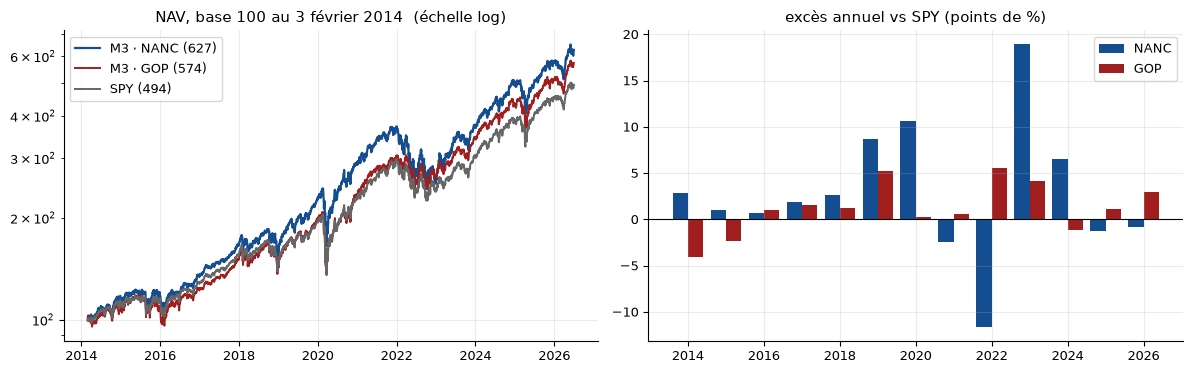

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(M3["NANC"].index, M3["NANC"], color=BLEU,  lw=1.6, label=f"M3 · NANC ({M3['NANC'].iloc[-1]:.0f})")
ax[0].plot(M3["GOP"].index,  M3["GOP"],  color=ROUGE, lw=1.4, label=f"M3 · GOP ({M3['GOP'].iloc[-1]:.0f})")
ax[0].plot(nav_spy_m3.index, nav_spy_m3, color=GRIS,  lw=1.4, label=f"SPY ({nav_spy_m3.iloc[-1]:.0f})")
ax[0].set_yscale("log"); ax[0].set_title("NAV, base 100 au 3 février 2014  (échelle log)"); ax[0].legend()
ax[1].bar(xN_.index - 0.2, xN_.values, width=0.4, color=BLEU,  label="NANC")
ax[1].bar(xG_.index + 0.2, xG_.values, width=0.4, color=ROUGE, label="GOP")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("excès annuel vs SPY (points de %)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_nav.png", dpi=150, bbox_inches="tight"); plt.show()

### §6.3 — À quoi ressemble le portefeuille

In [26]:
i_fin = coupes[-2]
lignes, tops = [], {}
for nom in ["NANC", "GOP"]:
    w = 100 * pd.Series(WPM[("M3 · $ × élus", nom)][i_fin]).sort_values(ascending=False)
    mx, t5, ne = conc(w)
    n_cap = int((w > 100*CAP - 1e-9).sum())            # combien de lignes touchent effectivement le plafond
    lignes.append({"fonds": nom, "titres": len(w), "plus gros poids %": mx, "top-5 %": t5, "N_eff": ne,
                   "lignes au plafond": n_cap})
    tops[nom] = w.head(10).round(2)
display(pd.DataFrame(lignes).set_index("fonds"))
print(f"\ntop-10 à la coupe du {cal[i_fin].date()} :")
display(pd.DataFrame(tops).fillna(""))
print("\nnombre de lignes au plafond, en médiane sur toutes les coupes :")
for nom in ["NANC", "GOP"]:
    m = np.median([sum(1 for x in w.values() if x > CAP - 1e-9)
                   for w in WPM[("M3 · $ × élus", nom)].values() if w])
    print(f"   {nom} : {m:.0f}")

,titres,plus gros poids %,top-5 %,N_eff,lignes au plafond
fonds,,,,,
NANC,150,8.5,40.0,23.4,2
GOP,150,8.5,32.3,33.3,1



top-10 à la coupe du 2026-05-29 :


,NANC,GOP
AAPL,6.57,8.31
AMD,,2.17
AMZN,8.24,3.24
AVGO,6.3,
COP,,1.99
GOOG,8.5,4.21
META,3.4,3.7
MSFT,8.22,8.5
NFLX,1.44,
NVDA,8.5,6.42



nombre de lignes au plafond, en médiane sur toutes les coupes :
   NANC : 2
   GOP : 1


## §7 — D'où vient l'excès : dollars, consensus, ou ni l'un ni l'autre ?

Le score mélange deux informations. On les sépare **à univers identique** — les 150 titres restent ceux que
le score complet désigne, seule la *pondération* change :

| variante | poids | ce qu'elle isole |
|---|---|---|
| **M2 · dollars purs** | $w \propto B_i$ | l'argent misé, sans le consensus |
| **élus seuls** | $w \propto m_i$ | le consensus, sans l'argent |
| **équipondéré** | $w = 1/150$ | ni l'un ni l'autre : la sélection seule |
| **M3** | $w \propto B_i m_i$ | les deux |

C'est une **décomposition**, pas une compétition : le verdict de la méthode se lit sur la ligne M3, quoi que
disent les autres.

In [27]:
ORD = ["équipondéré", "élus seuls", "M2 · dollars purs", "M3 · $ × élus"]
DEC = pd.DataFrame([bilan_ic(SER[(m, nom)], f"{m} — {nom}") for nom in ["NANC", "GOP"] for m in ORD]).set_index("run")
display(DEC[["excès %/an", "t", "IC bas", "IC haut", "α %/an", "β", "NAV"]].round(2))

# les mêmes runs vus par le modèle à quatre facteurs : un repère n'a de sens qu'à filtre ET univers identiques
# à ce qu'il éclaire — ces lignes sont donc toutes à θ = ∞, comme M3.
DECF = pd.DataFrame([facteurs(SER[(m, nom)], f"{m} — {nom}") for nom in ["NANC", "GOP"] for m in ORD]).set_index("run")
display(DECF[["α %/an", "t_α"] + FACS].round(3))

,excès %/an,t,IC bas,IC haut,α %/an,β,NAV
run,,,,,,,
équipondéré — NANC,-1.38,-1.45,-3.46,0.70,-0.95,0.98,430.18
élus seuls — NANC,-0.65,-0.91,-2.22,0.92,-0.41,0.99,463.52
M2 · dollars purs — NANC,1.27,0.93,-1.70,4.24,0.25,1.05,545.06
M3 · $ × élus — NANC,2.88,1.42,-1.53,7.29,1.22,1.08,627.10
équipondéré — GOP,-1.08,-0.71,-4.39,2.22,-0.67,0.96,447.77
élus seuls — GOP,-0.78,-0.75,-3.04,1.49,-0.17,0.96,465.58
M2 · dollars purs — GOP,0.50,0.26,-3.60,4.60,0.18,1.00,523.35
M3 · $ × élus — GOP,1.21,1.56,-0.48,2.90,1.09,1.00,573.66


,α %/an,t_α,Mkt-RF,SMB,HML,Mom
run,,,,,,
équipondéré — NANC,0.052,0.055,0.955,0.018,0.140,-0.097
élus seuls — NANC,0.384,0.495,0.962,-0.039,0.097,-0.094
M2 · dollars purs — NANC,0.904,1.206,1.015,-0.062,-0.052,-0.077
M3 · $ × élus — NANC,1.710,1.760,1.043,-0.122,-0.132,-0.082
équipondéré — GOP,0.415,0.430,0.938,0.039,0.212,-0.100
élus seuls — GOP,0.589,0.728,0.938,-0.057,0.148,-0.099
M2 · dollars purs — GOP,1.251,1.042,0.974,0.059,0.172,-0.085
M3 · $ × élus — GOP,1.647,1.808,0.979,-0.079,0.058,-0.072


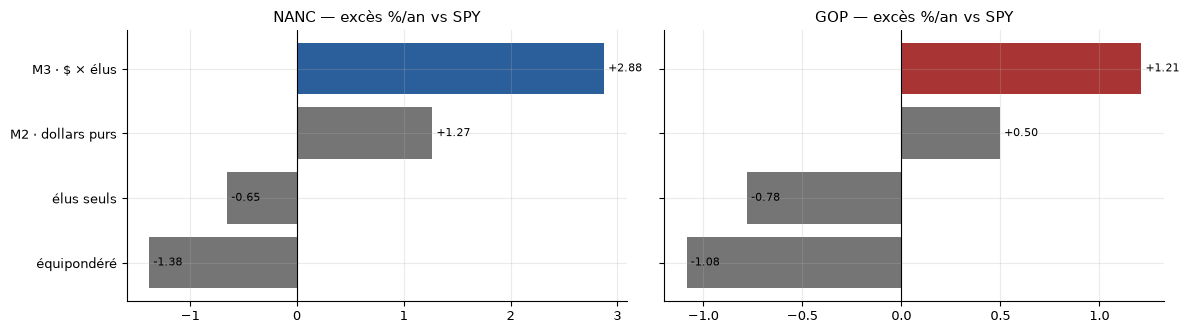

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for k, nom in enumerate(["NANC", "GOP"]):
    v = [bilan(SER[(m, nom)], m)["excès %/an"] for m in ORD]
    ax[k].barh(range(len(ORD)), v, color=[GRIS, GRIS, GRIS, BLEU if nom == "NANC" else ROUGE], alpha=.9)
    ax[k].set_yticks(range(len(ORD))); ax[k].set_yticklabels(ORD)
    ax[k].axvline(0, color="k", lw=.8); ax[k].set_title(f"{nom} — excès %/an vs SPY")
    for j, x in enumerate(v): ax[k].text(x, j, f" {x:+.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_decomposition.png", dpi=150, bbox_inches="tight"); plt.show()

### §7.1 — Le filtre anti-bruit, et son balayage publié en entier

Un élu qui déclare 300 opérations le même jour ne prend pas 300 décisions : son courtier rééquilibre un
mandat. Le filtre écarte toute opération issue d'un dépôt de $\theta$ opérations ou plus.

**$\theta = 50$ est la valeur déclarée d'avance** — elle vient de la description d'un gérant du fonds, pas
d'un réglage sur nos rendements. Le balayage ci-dessous est publié **en entier** pour montrer la pente ; il
ne sert pas à choisir. M3 n'applique pas le filtre ; M4 l'applique.

In [29]:
for parti, nom in PARTIS:
    tot = df[(df.party == parti) & (df.op == "buy")].A.sum()
    ecarte = df[(df.party == parti) & (df.op == "buy") & (df.taille_depot >= SEUIL_BRUIT)].A.sum()
    print(f"{nom} : le filtre θ={SEUIL_BRUIT} écarte {100*ecarte/tot:.0f} % du $ acheté "
          f"({ecarte/1e6:,.0f} M$ sur {tot/1e6:,.0f})")

BAL = []
for nom in ["NANC", "GOP"]:
    for lab in ["θ = 10", "θ = 20", "M4 · + filtre θ=50", "θ = 100", "M3 · $ × élus"]:
        b = bilan(SER[(lab, nom)], lab)
        BAL.append({"fonds": nom, "θ": {"M4 · + filtre θ=50": "θ = 50  (M4)",
                                        "M3 · $ × élus": "θ = ∞  (M3)"}.get(lab, lab),
                    "excès %/an": b["excès %/an"], "t": b["t"], "α %/an": b["α %/an"], "NAV": b["NAV"]})
display(pd.DataFrame(BAL).set_index(["fonds", "θ"]).round(2))
print("↑ balayage publié en entier — le verdict de la méthode se lit à θ = ∞ (M3), celui de M4 à θ = 50")

NANC : le filtre θ=50 écarte 54 % du $ acheté (388 M$ sur 716)


GOP : le filtre θ=50 écarte 58 % du $ acheté (514 M$ sur 891)


excès %/an     t  α %/an     NAV
fonds θ                                             
NANC  θ = 10              4.03  0.95    0.22  597.93
      θ = 20              3.88  0.94    0.22  593.99
      θ = 50  (M4)        4.47  1.15    0.90  651.27
      θ = 100             3.99  1.14    0.81  641.24
      θ = ∞  (M3)         2.88  1.42    1.22  627.10
GOP   θ = 10              2.94  1.65    2.62  699.83
      θ = 20              2.03  1.33    1.76  630.46
      θ = 50  (M4)        1.51  1.03    1.59  594.89
      θ = 100             1.65  1.67    1.65  605.82
      θ = ∞  (M3)         1.21  1.56    1.09  573.66

↑ balayage publié en entier — le verdict de la méthode se lit à θ = ∞ (M3), celui de M4 à θ = 50


## §8 — Première épreuve : le risque

Un excès peut n'être qu'un pari de style rémunéré. On régresse donc sur les quatre facteurs de
Fama-French-Carhart, et on regarde ce qui survit.

**Lecture des chargements** : $\beta_S < 0$ = le portefeuille penche vers les **grandes** capitalisations ;
$\beta_H < 0$ = vers la **croissance** plutôt que la *value* ; $\beta_U$ = exposition au **momentum**.

In [30]:
FAC = pd.DataFrame([facteurs(M3[nom], f"M3 · {nom}") for nom in ["NANC", "GOP"]]
                   + [facteurs(nav_spy_full, "SPY (repère)")]).set_index("run")
display(FAC[["α %/an", "t_α"] + FACS + ["n j"]].round(3))
print("\nà comparer à l'α du modèle marché seul :")
display(pd.DataFrame([bilan(M3[nom], f"M3 · {nom}") for nom in ["NANC", "GOP"]]).set_index("run")[["α %/an", "t_α", "β"]].round(3))

,α %/an,t_α,Mkt-RF,SMB,HML,Mom,n j
run,,,,,,,
M3 · NANC,1.710,1.760,1.043,-0.122,-0.132,-0.082,3059
M3 · GOP,1.647,1.808,0.979,-0.079,0.058,-0.072,3059
SPY (repère),0.040,0.115,0.980,-0.123,0.012,-0.009,3352



à comparer à l'α du modèle marché seul :


,α %/an,t_α,β
run,,,
M3 · NANC,1.223,1.034,1.077
M3 · GOP,1.090,1.067,1.003


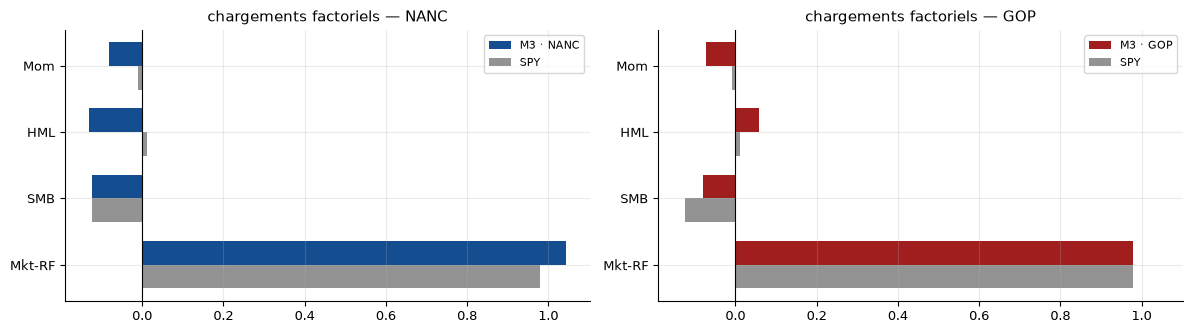

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for k, nom in enumerate(["NANC", "GOP"]):
    v = [FAC.loc[f"M3 · {nom}", c] for c in FACS]
    s = [FAC.loc["SPY (repère)", c] for c in FACS]
    y = np.arange(len(FACS))
    ax[k].barh(y + .18, v, height=.36, color=BLEU if nom == "NANC" else ROUGE, label=f"M3 · {nom}")
    ax[k].barh(y - .18, s, height=.36, color=GRIS, alpha=.7, label="SPY")
    ax[k].set_yticks(y); ax[k].set_yticklabels(FACS); ax[k].axvline(0, color="k", lw=.8)
    ax[k].set_title(f"chargements factoriels — {nom}"); ax[k].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_facteurs.png", dpi=150, bbox_inches="tight"); plt.show()

### §8.1 — $\alpha$ et $\beta$ glissants sur 252 jours

Les chiffres ci-dessus sont *plein-échantillon* : ils écrasent douze ans en un nombre. On les regarde au fil
du temps, sur une fenêtre glissante d'un an :
$\;\hat\beta_t = \mathrm{cov}_W(y,x)/\mathrm{var}_W(x)$, $\;\hat\alpha_t = (\bar y_W - \hat\beta_t \bar x_W)\times 252$.

NANC — β glissant méd 1.05 [0.96 ; 1.26] σ 0.07  ·  α glissant méd +1.70 %/an [-11.3 ; +11.3] · α > 0 70 % du temps
GOP — β glissant méd 0.99 [0.89 ; 1.13] σ 0.05  ·  α glissant méd +1.65 %/an [-6.3 ; +7.7] · α > 0 71 % du temps


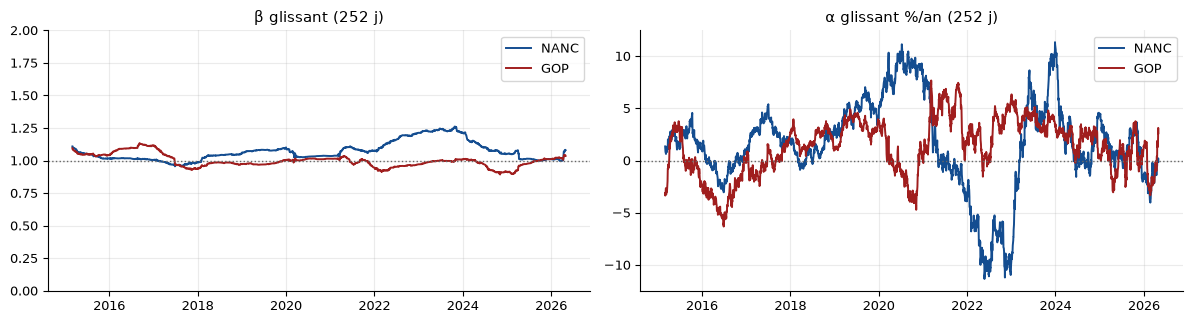

In [32]:
RA = {nom: roll_ab(M3[nom]) for nom in ["NANC", "GOP"]}
for nom in ["NANC", "GOP"]:
    aa, bb, _, _ = RA[nom]
    print(f"{nom} — β glissant méd {bb.median():.2f} [{bb.min():.2f} ; {bb.max():.2f}] σ {bb.std():.2f}  ·  "
          f"α glissant méd {aa.median():+.2f} %/an [{aa.min():+.1f} ; {aa.max():+.1f}] · α > 0 {100*(aa>0).mean():.0f} % du temps")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    aa, bb, _, _ = RA[nom]
    ax[0].plot(bb.index, bb, color=c, lw=1.4, label=nom)
    ax[1].plot(aa.index, aa, color=c, lw=1.4, label=nom)
ax[0].axhline(1, color=GRIS, ls=":", lw=1); ax[0].set_ylim(0, 2)
ax[0].set_title(f"β glissant ({Wab} j)"); ax[0].legend()
ax[1].axhline(0, color=GRIS, ls=":", lw=1); ax[1].set_title(f"α glissant %/an ({Wab} j)"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_rolling.png", dpi=150, bbox_inches="tight"); plt.show()

### §8.2 — Validation : le glissant est bien une régression

`cov/var` et `ȳ − β x̄` doivent redonner, sur une fenêtre donnée, exactement ce que rendrait une régression
des moindres carrés. Et le $\beta$ calculé sur l'échantillon entier doit retomber sur celui du §6.

In [33]:
for nom in ["NANC", "GOP"]:
    aa, bb, y, x = RA[nom]
    # (1) sur la dernière fenêtre de 252 jours, comparer à np.polyfit
    yy, xx = y.iloc[-Wab:].values, x.iloc[-Wab:].values
    b_p, a_p = np.polyfit(xx, yy, 1)
    assert abs(bb.iloc[-1] - b_p) < 1e-9,       f"{nom} : β glissant ≠ polyfit ({bb.iloc[-1]:.9f} vs {b_p:.9f})"
    assert abs(aa.iloc[-1] - a_p*252*100) < 1e-6, f"{nom} : α glissant ≠ polyfit"
    # (2) le β plein-échantillon du même chemin doit retomber sur celui du bilan
    b_full = np.polyfit(x.values, y.values, 1)[0]
    assert abs(b_full - MES[(nom, "β")]) < 1e-9, f"{nom} : β plein-échantillon {b_full:.6f} ≠ bilan {MES[(nom,'β')]:.6f}"
    print(f"✅ {nom} — glissant ≡ polyfit (β {bb.iloc[-1]:.6f}) · β plein-échantillon {b_full:.4f} ≡ celui du §6")

✅ NANC — glissant ≡ polyfit (β 1.079782) · β plein-échantillon 1.0771 ≡ celui du §6
✅ GOP — glissant ≡ polyfit (β 1.035953) · β plein-échantillon 1.0035 ≡ celui du §6


## §9 — Seconde épreuve : le coût

Une méthode qui se recompose sans arrêt paie des frais sans arrêt. Deux questions, dans l'ordre.

**Ce que ça coûte.** La rotation d'une coupe est
$\;\mathrm{TO}_t = \tfrac12 \sum_i |w^{\text{réalisé}}_i - w^{\text{dérivé}}_i|$, et on facture
$V_t \leftarrow V_t\,(1 - 2\,\mathrm{TO}_t\,c)$ avec $c = 10$ points de base (0,10 %) — le facteur 2 parce
qu'on paie à l'achat **et** à la vente.

**Faut-il ralentir.** On peut brider la rotation à $\tau_{\max}$ par mois :
$\lambda_R = \min(1, \tau_{\max}/\mathrm{TO}_t)$, actif seulement quand $\mathrm{TO}_t > \tau_{\max}$. Le
balayage est **publié en entier**, et la règle est écrite d'avance : *on ne retient le frein que s'il
améliore les deux partis*.

**Pourquoi M3 est lente.** Sa fenêtre fait trois ans : d'un mois sur l'autre, un trente-sixième du signal se
renouvelle. Une méthode à fenêtre d'un mois en renouvelle la moitié.

In [34]:
COUT_BPS = 10.0                                   # pb par aller-retour — DÉCLARÉ AVANT tout résultat
PLAFONDS = [np.inf, 0.25, 0.10, 0.05, 0.02]       # τ_max testés, publiés en entier

def rotation(WP, tau_max=np.inf, cuts=None):
    # rotation RÉALISÉE, telle que le moteur la produit (≠ celle de la cible dès que le frein mord)
    cuts = coupes if cuts is None else cuts
    _, tr = run_livre(WP, tau_max, cuts=cuts)
    idx = pd.DatetimeIndex([cal[cuts[j]+1] for j in range(1, len(cuts)-1)][:len(tr)])
    s   = pd.Series(tr, index=idx)
    n   = s.groupby(s.index.year).size()
    return s, 100*s.groupby(s.index.year).sum()[n[n >= 6].index]     # années complètes seulement

VIT, ROT = [], {}
for nom in ["NANC", "GOP"]:
    mens, an = rotation(WPM[("M3 · $ × élus", nom)])
    ROT[nom] = an
    VIT.append({"fonds": nom, "rotation méd. %/mois": 100*mens.median(),
                "rotation méd. %/an": an.median(), "rotation moy. %/an": an.mean(),
                "min %/an": an.min(), "max %/an": an.max()})
display(pd.DataFrame(VIT).set_index("fonds").round(1))
print("le fonds réel publie 44 · 62 · 10 % pour NANC et 46 · 54 · 16 % pour GOP (exercices 2023, 2024, 2025)")
print("⚠️ moyenne ≫ médiane : quelques années de forte recomposition tirent le coût — c'est la MOYENNE qui le fixe")

,rotation méd. %/mois,rotation méd. %/an,rotation moy. %/an,min %/an,max %/an
fonds,,,,,
NANC,4.9,64.9,71.7,32.4,140.4
GOP,5.3,68.3,76.8,36.0,164.6


le fonds réel publie 44 · 62 · 10 % pour NANC et 46 · 54 · 16 % pour GOP (exercices 2023, 2024, 2025)
⚠️ moyenne ≫ médiane : quelques années de forte recomposition tirent le coût — c'est la MOYENNE qui le fixe


In [35]:
COUT = []
for nom in ["NANC", "GOP"]:
    brut = SER[("M3 · $ × élus", nom)]
    net  = run_livre(WPM[("M3 · $ × élus", nom)], np.inf, cout_bps=COUT_BPS)[0]
    bb, bn = bilan(brut, nom), bilan(net, nom)
    COUT.append({"fonds": nom, "excès brut %/an": bb["excès %/an"], "excès net %/an": bn["excès %/an"],
                 "coût pt/an": bb["excès %/an"] - bn["excès %/an"],
                 "α₄ brut": facteurs(brut, nom)["α %/an"], "α₄ net": facteurs(net, nom)["α %/an"],
                 "NAV brute": bb["NAV"], "NAV nette": bn["NAV"]})
display(pd.DataFrame(COUT).set_index("fonds").round(2))

,excès brut %/an,excès net %/an,coût pt/an,α₄ brut,α₄ net,NAV brute,NAV nette
fonds,,,,,,,
NANC,2.88,2.71,0.17,1.71,1.56,627.10,614.90
GOP,1.21,1.04,0.18,1.65,1.49,573.66,561.75


In [36]:
# VALIDATION §9 — contrôle EXACT : les poids étant invariants d'échelle, facturer des frais ne change pas
# les rotations, seulement le niveau de la NAV. Donc NAV_nette / NAV_brute doit valoir exactement
#     ∏_t (1 − 2·TO_t·c)   sur TOUTES les coupes, premier déploiement compris (TO = ½ : on achète tout une fois).
for nom in ["NANC", "GOP"]:
    WP = WPM[("M3 · $ × élus", nom)]
    brut = run_livre(WP, np.inf)[0]
    net, tr = run_livre(WP, np.inf, cout_bps=COUT_BPS)
    facteur = (1 - 2*0.5*COUT_BPS/1e4) * np.prod(1 - 2*tr*COUT_BPS/1e4)   # ½ = le 1er déploiement
    observe = net.iloc[-1] / brut.iloc[-1]
    assert abs(observe - facteur) < 1e-12, f"{nom} : ratio {observe:.12f} ≠ ∏(1−2·TO·c) = {facteur:.12f}"
    print(f"✅ {nom} — NAV nette / NAV brute = {observe:.9f} ≡ ∏(1 − 2·TO·c) sur {len(tr)+1} coupes "
          f"(écart {abs(observe-facteur):.1e})")
    print(f"     soit {brut.iloc[-1]:.2f} → {net.iloc[-1]:.2f} · rotation moyenne {ROT[nom].mean():.0f} %/an "
          f"× 2 × {COUT_BPS:.0f} pb ≈ {2*ROT[nom].mean()/100*COUT_BPS/1e4*100:.2f} pt/an")

✅ NANC — NAV nette / NAV brute = 0.980542741 ≡ ∏(1 − 2·TO·c) sur 148 coupes (écart 2.6e-15)
     soit 627.10 → 614.90 · rotation moyenne 72 %/an × 2 × 10 pb ≈ 0.14 pt/an
✅ GOP — NAV nette / NAV brute = 0.979244408 ≡ ∏(1 − 2·TO·c) sur 148 coupes (écart 1.1e-16)
     soit 573.66 → 561.75 · rotation moyenne 77 %/an × 2 × 10 pb ≈ 0.15 pt/an


### §9.1 — Faut-il ralentir ? Le balayage du frein, net de frais

La règle a été écrite avant de regarder : **on ne retient le frein que s'il améliore les deux partis.**

excès net %/an     t  α %/an     NAV
fonds τ_max                                          
NANC  aucun                2.71  1.34    1.07  614.90
      25 %/mois            2.72  1.35    1.08  615.62
      10 %/mois            2.74  1.36    1.10  617.60
      5 %/mois             2.78  1.38    1.16  620.71
      2 %/mois             2.83  1.45    1.33  628.39
GOP   aucun                1.04  1.31    0.93  561.75
      25 %/mois            1.00  1.23    0.89  559.27
      10 %/mois            0.98  1.21    0.88  558.25
      5 %/mois             1.09  1.37    1.07  568.64
      2 %/mois             0.62  0.80    0.86  542.00

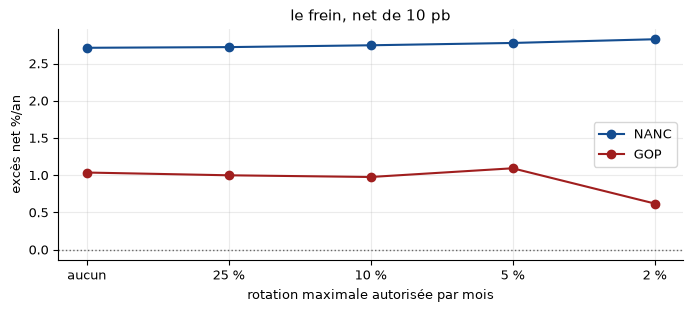

gain (ou perte) par rapport à l'absence de frein, en points de % par an :
    25 %/mois — NANC +0.01 · GOP -0.04   → min -0.04
    10 %/mois — NANC +0.03 · GOP -0.06   → min -0.06
     5 %/mois — NANC +0.06 · GOP +0.06   → min +0.06
     2 %/mois — NANC +0.11 · GOP -0.42   → min -0.42

→ RÈGLE DÉCLARÉE D'AVANCE : le frein n'est retenu que s'il améliore les DEUX partis.
   plafonds qui passent la règle : ['5 %/mois']

   profil du gain minimal, du plafond le plus lâche au plus serré :
      -0.04 → -0.06 → +0.06 → -0.42
   2 changement(s) de signe sur 3 pas.
   ⚠️ le seul plafond qui passe la règle est ENTOURÉ de plafonds qui échouent. Serrer la
      contrainte devrait agir dans un sens, pas alterner : ce profil est celui du bruit, pas
      d'un effet. Le gain de +0.06 pt est du même ordre que l'écart entre voisins.
   → le frein n'est PAS retenu : la règle est nécessaire, elle n'est pas suffisante.


In [37]:
FREIN = []
for nom in ["NANC", "GOP"]:
    for tm in PLAFONDS:
        v = run_livre(WPM[("M3 · $ × élus", nom)], tm, cout_bps=COUT_BPS)[0]
        b = bilan(v, nom)
        FREIN.append({"fonds": nom, "τ_max": "aucun" if tm == np.inf else f"{100*tm:.0f} %/mois",
                      "excès net %/an": b["excès %/an"], "t": b["t"], "α %/an": b["α %/an"], "NAV": b["NAV"]})
FREIN = pd.DataFrame(FREIN)
display(FREIN.set_index(["fonds", "τ_max"]).round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    s = FREIN[FREIN.fonds == nom]
    ax.plot(range(len(PLAFONDS)), s["excès net %/an"].values, "o-", color=c, lw=1.5, label=nom)
ax.set_xticks(range(len(PLAFONDS))); ax.set_xticklabels(["aucun", "25 %", "10 %", "5 %", "2 %"])
ax.set_xlabel("rotation maximale autorisée par mois"); ax.set_ylabel("excès net %/an")
ax.axhline(0, color=GRIS, ls=":", lw=1); ax.set_title(f"le frein, net de {COUT_BPS:.0f} pb"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_frein.png", dpi=150, bbox_inches="tight"); plt.show()

g = FREIN[FREIN["τ_max"] != "aucun"].merge(
    FREIN[FREIN["τ_max"] == "aucun"][["fonds", "excès net %/an"]].rename(columns={"excès net %/an": "sans frein"}),
    on="fonds")
g["gain pt"] = g["excès net %/an"] - g["sans frein"]
lbl = [f"{100*tm:.0f} %/mois" for tm in PLAFONDS[1:]]                 # du plus lâche au plus serré
print("gain (ou perte) par rapport à l'absence de frein, en points de % par an :")
for k in lbl:
    s = g[g["τ_max"] == k].set_index("fonds")["gain pt"]
    print(f"   {k:>10s} — NANC {s['NANC']:+.2f} · GOP {s['GOP']:+.2f}   → min {s.min():+.2f}")
ok = g.groupby("τ_max")["gain pt"].min()
gagnants = [k for k in lbl if ok[k] > 0]
print(f"\n→ RÈGLE DÉCLARÉE D'AVANCE : le frein n'est retenu que s'il améliore les DEUX partis.")
print(f"   aucun plafond ne le fait — le frein n'est pas retenu" if not gagnants
      else f"   plafonds qui passent la règle : {gagnants}")

# ── le test qui tranche : un effet réel serait MONOTONE en τ_max ──
serie = [ok[k] for k in lbl]                      # du plus lâche (25 %) au plus serré (2 %)
signes = [np.sign(x) for x in serie]
alterne = sum(1 for a, b in zip(signes, signes[1:]) if a != b)
print(f"\n   profil du gain minimal, du plafond le plus lâche au plus serré :")
print("      " + " → ".join(f"{ok[k]:+.2f}" for k in lbl))
print(f"   {alterne} changement(s) de signe sur {len(lbl)-1} pas.")
if gagnants and alterne >= 2:
    print(f"   ⚠️ le seul plafond qui passe la règle est ENTOURÉ de plafonds qui échouent. Serrer la")
    print(f"      contrainte devrait agir dans un sens, pas alterner : ce profil est celui du bruit, pas")
    print(f"      d'un effet. Le gain de {max(ok):+.2f} pt est du même ordre que l'écart entre voisins.")
    print(f"   → le frein n'est PAS retenu : la règle est nécessaire, elle n'est pas suffisante.")

## §10 — Ce qui est prêt pour la variante ETF

**Aucune mesure dans cette section.** La question posée est : *et si, au lieu d'acheter les titres que les
élus achètent, on achetait l'ETF sectoriel correspondant ?* Un achat de NVDA devient un achat de XLK. Cette
section inventorie ce que le notebook a déjà sous la main, et **énonce les trois problèmes avant de calculer
quoi que ce soit** — pour qu'aucune réponse ne puisse être un réglage trouvé après coup.

### Ce qui est déjà là
- la colonne `etf_proxy`, chargée au §1.1, renseignée sur **100 %** des lignes (mapping GICS → SPDR) ;
- les **onze** séries de prix SPDR, chargées au §1.3, sans effet sur le flux (prouvé au §1.5) ;
- le point de substitution `_instrument()` au §4 : `univers="etf"` suffit, le moteur ne bouge pas d'une ligne.

### Les trois problèmes, énoncés d'avance
1. **Le plafond ne peut plus exister.** $\lceil 1/c \rceil = 12 > 11$ : aucun vecteur de somme 1 ne
   respecte 8,5 % sur onze lignes. `cap_poids` aplatit et renormalise — il rendrait l'**équipondéré**, et on
   ne mesurerait plus M3 mais « un onzième par secteur ». Il n'existe **aucune transposition honnête** du
   8,5 % : ce nombre vient de la concentration observée d'un fonds de 150 lignes, et il n'existe pas de fonds
   réel de 11 secteurs dont on lirait l'équivalent.
2. **La sélection disparaît.** $|\mathcal{U}| = 11 < N = 150$ : le top-150 ne coupe plus rien. Or la
   sélection est le seul levier qui ait jamais fait une différence dans ce projet.
3. **Deux secteurs n'existent pas au début.** XLRE ne cote qu'à partir d'octobre 2015, XLC de juin 2018 —
   sur un historique qui démarre en 2014. Laisser `vivant()` faire son travail est gratuit et sans regard
   vers le futur, mais **réaffecte le poids de ces secteurs vers les autres**, ce qui n'est pas neutre.

In [38]:
# (1) ce que pèsent les deux secteurs absents au début, en $ acheté et en coupes
dispo = {t: cal[NFIRST[t]].date() for t in ETF_SECT}
print("première cotation des 11 SPDR :")
print("   " + " · ".join(f"{t} {d}" for t, d in sorted(dispo.items(), key=lambda kv: kv[1])))

for t in ["XLRE", "XLC"]:
    d0 = cal[NFIRST[t]]
    nc = sum(1 for i in coupes[:-1] if i < NFIRST[t])
    print(f"\n{t} — cote à partir du {d0.date()} · {nc} coupes sur {len(coupes)-1} sans lui")
    for parti, nom in PARTIS:
        m = (df.party == parti) & (df.op == "buy")
        avant = m & (df.disclosure_date < d0)
        # ce qui compte : SUR LA PÉRIODE OÙ LE SECTEUR N'EXISTE PAS, quelle part du signal serait réaffectée
        part_per = df.loc[avant & (df.etf_proxy == t), "A"].sum() / df.loc[avant, "A"].sum()
        part_tot = df.loc[avant & (df.etf_proxy == t), "A"].sum() / df.loc[m, "A"].sum()
        print(f"     {nom} : {100*part_per:.1f} % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs "
              f"({100*part_tot:.1f} % du $ de tout l'échantillon)")

première cotation des 11 SPDR :
   XLB 2012-01-03 · XLE 2012-01-03 · XLF 2012-01-03 · XLI 2012-01-03 · XLK 2012-01-03 · XLP 2012-01-03 · XLU 2012-01-03 · XLV 2012-01-03 · XLY 2012-01-03 · XLRE 2015-10-08 · XLC 2018-06-19

XLRE — cote à partir du 2015-10-08 · 20 coupes sur 148 sans lui
     NANC : 0.7 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (0.1 % du $ de tout l'échantillon)
     GOP : 1.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (0.2 % du $ de tout l'échantillon)

XLC — cote à partir du 2018-06-19 · 52 coupes sur 148 sans lui
     NANC : 7.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (1.5 % du $ de tout l'échantillon)
     GOP : 7.0 % du $ acheté SUR CETTE PÉRIODE serait réaffecté aux autres secteurs (2.4 % du $ de tout l'échantillon)


In [39]:
# (2) à quoi ressemblerait l'univers sectoriel : le score agrégé par secteur, à la dernière coupe
i1 = coupes[-2]
for parti, nom in PARTIS:
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
    s = (g.groupby("etf_proxy").A.sum() * g.groupby("etf_proxy").bioguide_id.nunique()).dropna()
    s = (100 * s / s.sum()).sort_values(ascending=False)
    print(f"\n{nom} — score par secteur à la coupe du {cal[i1].date()} (%, avant tout plafond) :")
    print("   " + " · ".join(f"{k} {v:.1f}" for k, v in s.items()))
    print(f"   plus gros secteur {s.iloc[0]:.1f} % · top-3 {s.head(3).sum():.1f} % · N_eff {1/((s/100)**2).sum():.1f}")


NANC — score par secteur à la coupe du 2026-05-29 (%, avant tout plafond) :
   XLK 45.2 · XLV 10.5 · XLY 9.6 · XLF 8.9 · XLC 8.7 · XLI 6.8 · XLP 5.0 · XLRE 2.1 · XLB 1.6 · XLE 0.8 · XLU 0.8
   plus gros secteur 45.2 % · top-3 65.3 % · N_eff 4.0

GOP — score par secteur à la coupe du 2026-05-29 (%, avant tout plafond) :
   XLK 31.9 · XLV 14.6 · XLI 13.1 · XLF 12.9 · XLY 8.5 · XLE 5.6 · XLC 4.9 · XLP 4.3 · XLB 2.5 · XLRE 1.1 · XLU 0.7
   plus gros secteur 31.9 % · top-3 59.5 % · N_eff 5.8


In [40]:
# (3) la démonstration que le plafond de 8,5 % est inapplicable à 11 instruments
demo = pd.Series([62.9, 10.4, 9.6, 4.2, 3.7, 3.4, 2.2, 1.9, 1.8, 0.05, 0.05], index=ETF_SECT)
out  = cap_poids(demo / demo.sum(), CAP)
print(f"score très concentré en entrée : {' · '.join(f'{100*x/demo.sum():.1f}' for x in demo.values)}")
print(f"après cap_poids à {100*CAP:.1f} %    : {' · '.join(f'{100*x:.1f}' for x in out.values)}")
print(f"écart max à l'équipondéré 1/11 = {100/11:.2f} % : {np.abs(out.values - 1/11).max():.1e}")
assert np.abs(out.values - 1/11).max() < 1e-12, "la démonstration devrait donner l'équipondéré exact"
print(f"\n⚠️ le plafond de {100*CAP:.1f} % appliqué à 11 instruments efface entièrement le score.")
print(f"   ⌈1/c⌉ = {math.ceil(1/CAP)} > 11 — il faudra trancher le plafond AVANT de lancer le premier run ETF.")

score très concentré en entrée : 62.8 · 10.4 · 9.6 · 4.2 · 3.7 · 3.4 · 2.2 · 1.9 · 1.8 · 0.0 · 0.0
après cap_poids à 8.5 %    : 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1 · 9.1
écart max à l'équipondéré 1/11 = 9.09 % : 1.4e-17

⚠️ le plafond de 8.5 % appliqué à 11 instruments efface entièrement le score.
   ⌈1/c⌉ = 12 > 11 — il faudra trancher le plafond AVANT de lancer le premier run ETF.


### §10.1 — Les deux arbitrages à trancher avant le premier calcul

**(a) Le plafond.** La seule option qui n'introduit aucun réglage est de le retirer et de publier les deux
bornes : `cap = 1` (le score pur, rien d'ajouté) et `cap = 1/11` (le plus petit plafond faisable, c'est-à-dire
l'équipondéré sectoriel). Tout résultat se situe alors entre les deux, et on n'a rien choisi. Reste à
décider s'il faut, pour comparer ce qui est comparable, rejouer **aussi** M3-titres sans plafond.

**(b) La fenêtre.** Garder 2014-2026 en laissant `vivant()` gérer les deux secteurs manquants, c'est
conserver treize années — mais le poids réaffecté part vers les secteurs qui ont le mieux performé, donc
**dans le sens du résultat**. Se restreindre à juin 2018 → 2026 supprime le biais mais tombe à huit années,
et impose de rejouer M3-titres sur la même fenêtre. La décision doit être écrite avant de voir les chiffres.

⚠️ **Ce qu'il ne faut pas faire** : substituer VOX à XLC avant 2018. Le secteur « Communication Services »
a été créé en septembre 2018 en absorbant Google et Meta (venus de la technologie) et Disney et Netflix
(venus de la consommation discrétionnaire). Le VOX d'avant 2018 ne contient pas les titres qui *font* ce
secteur : le substitut fabriquerait un rendement sans rapport avec ce qu'on cherche à mesurer.

## §11 — La variante ETF : acheter le secteur au lieu du titre

**La question.** Les élus achètent NVDA ; et si l'on achetait XLK, l'ETF du secteur technologique ? La règle
ne change pas d'une virgule — même fenêtre de trois ans, mêmes achats, même score $B_i \times m_i$, même
exécution au close J+1. **Seul l'instrument change** : chaque titre est remplacé par son ETF sectoriel, et
les scores s'agrègent en onze lignes au lieu de cent cinquante.

$$s_{\text{XLK},t} \;=\; \Big(\textstyle\sum_{k\,:\,\varphi(i_k)=\text{XLK}} A_k\Big) \times \#\{\text{élus ayant acheté un titre du secteur}\}$$

où $\varphi$ est la carte titre $\to$ secteur GICS $\to$ SPDR, déjà présente dans la donnée (`etf_proxy`).

### Les quatre runs, déclarés avant de les lancer

Les deux difficultés du §10 ont été tranchées **en publiant les deux côtés plutôt qu'en choisissant** :

| run | plafond | pourquoi il est là |
|---|---|---|
| **ETF · score** | aucun | la spécification pure : $w \propto B_i m_i$, rien d'ajouté |
| **ETF · équipondéré** | $1/11$ | le plus petit plafond *faisable* — donc la borne « pondération effacée » |
| **titres · score** | aucun | pour que la comparaison oppose deux runs **sans** plafond |
| **titres · M3** | 8,5 % | la référence publiée, rappelée pour situer |

Et deux fenêtres, pour la même raison : **2014-2026** (tout l'historique, mais deux secteurs manquent au
début) et **2019-2026** (la première année civile entière où les onze SPDR cotent tous).

**Ce qui est attendu, et qu'il faut écrire avant de regarder** : un portefeuille de onze secteurs est un
portefeuille de marché légèrement incliné. On s'attend à $\beta \approx 1$, à une volatilité plus basse, et
à un excès qui s'efface — c'est le résultat qu'avait obtenu un travail antérieur du projet sur une autre
méthode (dilution de 4,5 à 5,8 points d'alpha par an). Si c'est ce qu'on retrouve, ce n'est pas un échec :
c'est une mesure, et elle dit où vit l'information.

In [41]:
CAP_EQ = 1/11                                      # le plus petit plafond faisable sur 11 instruments
D19    = pd.Timestamp("2019-01-01")                # 1ʳᵉ année civile entière où les 11 SPDR cotent

KWE = {"ETF · score":        dict(univers="etf",    cap=1.0),
       "ETF · équipondéré":  dict(univers="etf",    cap=CAP_EQ),
       "titres · score":     dict(univers="titres", cap=1.0)}
WPE, SERE = {}, {}
t0 = time.time()
for parti, nom in PARTIS:
    for m, kw in KWE.items():
        WPE[(m, nom)] = cibles_methode(parti, **kw)
        SERE[(m, nom)] = run_livre(WPE[(m, nom)], np.inf)[0]
for nom in ["NANC", "GOP"]:                        # la référence publiée, déjà calculée
    WPE[("titres · M3 (cap 8,5 %)", nom)]  = WPM[("M3 · $ × élus", nom)]
    SERE[("titres · M3 (cap 8,5 %)", nom)] = SER[("M3 · $ × élus", nom)]

ORD_E = ["titres · M3 (cap 8,5 %)", "titres · score", "ETF · score", "ETF · équipondéré"]
n_lig = {m: int(np.median([len(WPE[(m, "NANC")][i]) for i in coupes[:-1] if WPE[(m, "NANC")][i]])) for m in ORD_E}
print(f"{len(KWE)*2} jeux de cibles calculés en {time.time()-t0:.1f} s")
print("lignes détenues (médiane, NANC) — " + " · ".join(f"{m} : {n}" for m, n in n_lig.items()))

6 jeux de cibles calculés en 5.3 s
lignes détenues (médiane, NANC) — titres · M3 (cap 8,5 %) : 150 · titres · score : 150 · ETF · score : 11 · ETF · équipondéré : 11


### §11.1 — Ce que ça donne, sur les deux fenêtres

In [42]:
def bilan_fen(V, nom, d0=None):
    return bilan_ic(V if d0 is None else V[V.index >= d0], nom)

for d0, lab in [(None, "2014-2026 — tout l'historique"), (D19, "2019-2026 — les 11 secteurs cotent tous")]:
    L = []
    for nom in ["NANC", "GOP"]:
        for m in ORD_E:
            b = bilan_fen(SERE[(m, nom)], f"{m} — {nom}" + ("" if d0 is None else " (2019+)"), d0)
            L.append({"run": b["run"], "excès %/an": b["excès %/an"], "t": b["t"], "n ans": b["n ans"],
                      "IC bas": b["IC bas"], "IC haut": b["IC haut"], "α %/an": b["α %/an"], "β": b["β"]})
    print(f"\n=== {lab} ===")
    display(pd.DataFrame(L).set_index("run").round(2))


=== 2014-2026 — tout l'historique ===


,excès %/an,t,n ans,IC bas,IC haut,α %/an,β
run,,,,,,,
"titres · M3 (cap 8,5 %) — NANC",2.88,1.42,13,-1.53,7.29,1.22,1.08
titres · score — NANC,5.95,2.35,13,0.43,11.48,3.57,1.12
ETF · score — NANC,1.93,1.87,13,-0.32,4.18,0.67,1.06
ETF · équipondéré — NANC,-2.40,-1.89,13,-5.16,0.36,-0.85,0.91
"titres · M3 (cap 8,5 %) — GOP",1.21,1.56,13,-0.48,2.90,1.09,1.00
titres · score — GOP,1.54,1.77,13,-0.36,3.44,1.34,1.00
ETF · score — GOP,-0.10,-0.09,13,-2.49,2.29,-0.25,1.01
ETF · équipondéré — GOP,-2.40,-1.89,13,-5.16,0.36,-0.85,0.91



=== 2019-2026 — les 11 secteurs cotent tous ===


,excès %/an,t,n ans,IC bas,IC haut,α %/an,β
run,,,,,,,
"titres · M3 (cap 8,5 %) — NANC (2019+)",3.51,1.05,8,-4.37,11.40,1.07,1.09
titres · score — NANC (2019+),7.96,2.09,8,-1.06,16.99,4.61,1.13
ETF · score — NANC (2019+),2.24,1.46,8,-1.40,5.89,0.56,1.05
ETF · équipondéré — NANC (2019+),-2.98,-1.47,8,-7.78,1.82,-0.88,0.91
"titres · M3 (cap 8,5 %) — GOP (2019+)",2.27,2.65,8,0.24,4.30,2.24,0.99
titres · score — GOP (2019+),2.17,2.36,8,-0.00,4.33,1.95,1.00
ETF · score — GOP (2019+),0.27,0.17,8,-3.60,4.14,0.19,1.01
ETF · équipondéré — GOP (2019+),-2.98,-1.47,8,-7.78,1.82,-0.88,0.91


In [43]:
# vol, concentration et rotation : un panier de 11 secteurs est-il vraiment plus sage ?
L = []
for nom in ["NANC", "GOP"]:
    for m in ORD_E:
        V = SERE[(m, nom)]
        w = 100 * pd.Series(WPE[(m, nom)][coupes[-2]]).sort_values(ascending=False)
        mx, t5, ne = conc(w)
        _, an = rotation(WPE[(m, nom)])
        L.append({"run": f"{m} — {nom}", "lignes": len(w), "plus gros %": mx, "top-5 %": t5, "N_eff": ne,
                  "vol %/an": 100*V.pct_change().std()*np.sqrt(252), "rotation moy. %/an": an.mean(),
                  "NAV": V.iloc[-1]})
display(pd.DataFrame(L).set_index("run").round(1))
print(f"repère : SPY vol {100*r_spy.std()*np.sqrt(252):.1f} %/an")

,lignes,plus gros %,top-5 %,N_eff,vol %/an,rotation moy. %/an,NAV
run,,,,,,,
"titres · M3 (cap 8,5 %) — NANC",150,8.5,40.0,23.4,19.1,71.7,627.1
titres · score — NANC,150,32.5,56.6,7.9,20.5,75.4,844.7
ETF · score — NANC,11,45.2,83.0,4.0,18.6,34.3,599.8
ETF · équipondéré — NANC,11,9.1,45.5,11.0,16.2,15.4,389.7
"titres · M3 (cap 8,5 %) — GOP",150,8.5,32.3,33.3,17.7,76.8,573.7
titres · score — GOP,150,9.0,32.6,32.7,17.7,79.0,587.7
ETF · score — GOP,11,31.9,80.9,5.8,17.8,30.9,501.0
ETF · équipondéré — GOP,11,9.1,45.5,11.0,16.2,15.4,389.7


repère : SPY vol 16.6 %/an


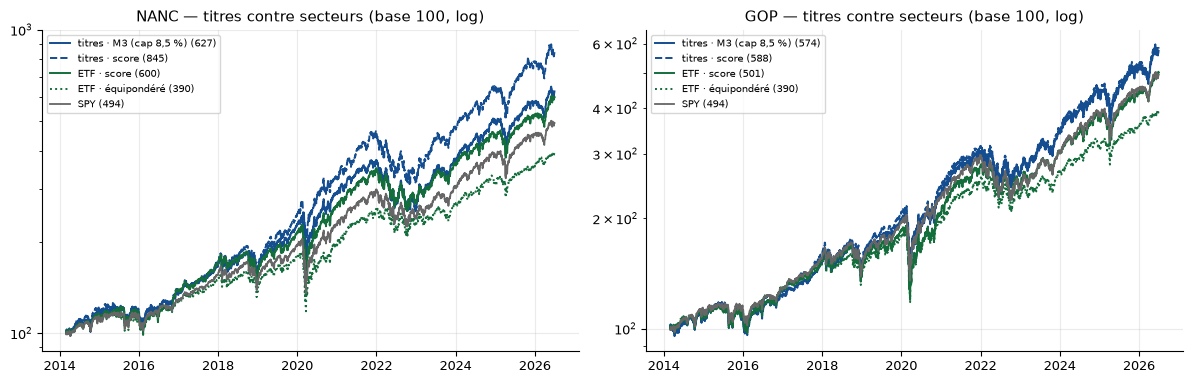

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
for k, nom in enumerate(["NANC", "GOP"]):
    base = SERE[("titres · M3 (cap 8,5 %)", nom)]
    sp   = (1 + r_spy.reindex(base.index).fillna(0)).cumprod() * 100
    for m, c, ls in [("titres · M3 (cap 8,5 %)", BLEU, "-"), ("titres · score", BLEU, "--"),
                     ("ETF · score", VERT, "-"), ("ETF · équipondéré", VERT, ":")]:
        V = SERE[(m, nom)]
        ax[k].plot(V.index, V, color=c, ls=ls, lw=1.4, label=f"{m} ({V.iloc[-1]:.0f})")
    ax[k].plot(sp.index, sp, color=GRIS, lw=1.3, label=f"SPY ({sp.iloc[-1]:.0f})")
    ax[k].set_yscale("log"); ax[k].set_title(f"{nom} — titres contre secteurs (base 100, log)")
    ax[k].legend(fontsize=7)
plt.tight_layout(); plt.savefig(f"{FIGS}/m3_etf_nav.png", dpi=150, bbox_inches="tight"); plt.show()

### §11.2 — Ce que le repli sur les secteurs manquants coûte vraiment

XLRE n'existe pas avant octobre 2015, XLC avant juin 2018. Quand un secteur manque, son poids ne disparaît
pas : il est **redistribué sur les autres**. On mesure ici, coupe par coupe, quelle fraction du score tombe
dans un secteur non coté — c'est exactement la part du signal qui part ailleurs qu'elle ne le devrait.

NANC — 52 coupes sur 148 avec un secteur manquant · part réaffectée : médiane 4.5 % · max 8.3 % · dernière 2018-05-31


GOP — 52 coupes sur 148 avec un secteur manquant · part réaffectée : médiane 5.5 % · max 11.2 % · dernière 2018-05-31


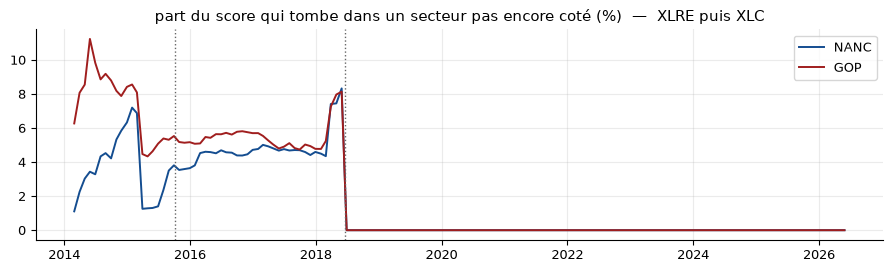

In [45]:
PERDU = {}
for parti, nom in PARTIS:
    ser = {}
    for i1 in coupes[:-1]:
        lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
        g = df.iloc[ordre_d[lo:hi]]; g = g[(g.party == parti) & (g.op == "buy")]
        if not len(g): continue
        s = (g.groupby("etf_proxy").A.sum() * g.groupby("etf_proxy").bioguide_id.nunique()).dropna()
        absent = [t for t in s.index if not (np.isfinite(PXV[t][i1+1]) and vivant(t, i1))]
        ser[cal[i1]] = 100 * s.reindex(absent).sum() / s.sum() if s.sum() > 0 else 0.0
    PERDU[nom] = pd.Series(ser)
    p = PERDU[nom][PERDU[nom] > 0]
    print(f"{nom} — {len(p)} coupes sur {len(coupes)-1} avec un secteur manquant · "
          f"part réaffectée : médiane {p.median():.1f} % · max {p.max():.1f} % · dernière {p.index[-1].date()}")

plt.figure(figsize=(9, 2.8))
for nom, c in [("NANC", BLEU), ("GOP", ROUGE)]:
    plt.plot(PERDU[nom].index, PERDU[nom].values, color=c, lw=1.4, label=nom)
plt.axvline(pd.Timestamp("2015-10-08"), color=GRIS, ls=":", lw=1)
plt.axvline(pd.Timestamp("2018-06-19"), color=GRIS, ls=":", lw=1)
plt.title("part du score qui tombe dans un secteur pas encore coté (%)  —  XLRE puis XLC")
plt.legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/m3_etf_manquant.png", dpi=150, bbox_inches="tight"); plt.show()

### §11.3 — Validations

In [46]:
# (1) l'univers ETF est bien contenu dans les 11 SPDR, et il se remplit aux dates d'inception
for nom in ["NANC", "GOP"]:
    for m in ["ETF · score", "ETF · équipondéré"]:
        u = set().union(*[set(w) for w in WPE[(m, nom)].values() if w])
        assert u <= set(ETF_SECT), f"{m}/{nom} : instrument hors des 11 SPDR — {u - set(ETF_SECT)}"
card = {cal[i].date(): len(WPE[("ETF · score", "NANC")][i]) for i in coupes[:-1]}
seq = sorted(set(card.values()))
print(f"✅ (1) l'univers ETF ⊆ les 11 SPDR · cardinaux observés : {seq}")
for n in seq:
    d = [k for k, v in card.items() if v == n]
    print(f"     {n} secteurs : {d[0]} → {d[-1]}  ({len(d)} coupes)")

# (2) Σw = 1 partout
for (m, nom), WP in WPE.items():
    for i, w in WP.items():
        if w: assert abs(sum(w.values()) - 1) < 1e-9, f"{m}/{nom} coupe {i} : Σw = {sum(w.values())}"
print(f"✅ (2) Σw = 1 à chaque coupe des {len(WPE)} jeux")

✅ (1) l'univers ETF ⊆ les 11 SPDR · cardinaux observés : [9, 10, 11]
     9 secteurs : 2014-02-28 → 2015-09-30  (20 coupes)
     10 secteurs : 2015-10-30 → 2018-05-31  (32 coupes)
     11 secteurs : 2018-06-29 → 2026-05-29  (96 coupes)
✅ (2) Σw = 1 à chaque coupe des 8 jeux


In [47]:
# (3) le plafond 1/11 rend bien l'équipondéré exact — c'est la démonstration du §10, sur les vrais poids
for nom in ["NANC", "GOP"]:
    ecart = max(np.abs(np.array(list(w.values())) - 1/len(w)).max()
                for w in WPE[("ETF · équipondéré", nom)].values() if w)
    assert ecart < 1e-12, f"{nom} : le run 'équipondéré' ne l'est pas (écart {ecart:.1e})"
print(f"✅ (3) le plafond 1/11 donne l'équipondéré exact sur toutes les coupes (écart max < 1e-12)")

# (4) contrôle de sanité : la variante ETF n'est PAS la variante titres
for nom in ["NANC", "GOP"]:
    a, b = SERE[("ETF · score", nom)].iloc[-1], SERE[("titres · score", nom)].iloc[-1]
    assert abs(a - b) > 1, f"{nom} : ETF et titres rendent la même NAV — la substitution n'a pas eu lieu"
    print(f"✅ (4) {nom} — NAV titres {b:.1f} ≠ NAV ETF {a:.1f} : la substitution a bien eu lieu")

# (5) l'équipondéré sectoriel ne DÉPEND PAS du parti : 11 secteurs à poids égaux, c'est le même portefeuille.
#     Les deux colonnes doivent donc coïncider dès que les deux partis couvrent les 11 secteurs.
comm = [i for i in coupes[:-1] if len(WPE[("ETF · équipondéré","NANC")][i]) == 11
                               and len(WPE[("ETF · équipondéré","GOP")][i])  == 11]
for i in comm:
    a, b = WPE[("ETF · équipondéré","NANC")][i], WPE[("ETF · équipondéré","GOP")][i]
    assert set(a) == set(b) and max(abs(a[k]-b[k]) for k in a) < 1e-15, f"coupe {i} : les deux diffèrent"
print(f"✅ (5) l'équipondéré sectoriel est IDENTIQUE pour les deux partis sur les {len(comm)} coupes à 11 secteurs")
print(f"     (c'est attendu : à poids égaux sur les mêmes 11 lignes, le parti ne joue plus aucun rôle —")
print(f"      les écarts de NAV sur 2014-26 viennent uniquement du début, quand les univers différaient)")

# (6) NON-RÉGRESSION : M3-titres publiée n'a pas bougé d'un iota
for nom in ["NANC", "GOP"]:
    assert abs(SER[("M3 · $ × élus", nom)].iloc[-1] - M3[nom].iloc[-1]) < 1e-9, f"{nom} : M3 a bougé"
print(f"\n✅ (6) non-régression — M3 sur les titres inchangée "
      f"(NAV {M3['NANC'].iloc[-1]:.2f} / {M3['GOP'].iloc[-1]:.2f}) : le §11 n'a touché à rien")

✅ (3) le plafond 1/11 donne l'équipondéré exact sur toutes les coupes (écart max < 1e-12)
✅ (4) NANC — NAV titres 844.7 ≠ NAV ETF 599.8 : la substitution a bien eu lieu
✅ (4) GOP — NAV titres 587.7 ≠ NAV ETF 501.0 : la substitution a bien eu lieu
✅ (5) l'équipondéré sectoriel est IDENTIQUE pour les deux partis sur les 96 coupes à 11 secteurs
     (c'est attendu : à poids égaux sur les mêmes 11 lignes, le parti ne joue plus aucun rôle —
      les écarts de NAV sur 2014-26 viennent uniquement du début, quand les univers différaient)

✅ (6) non-régression — M3 sur les titres inchangée (NAV 627.10 / 573.66) : le §11 n'a touché à rien


### §11.4 — Combien de choses a-t-on essayées ? La déclaration de multiplicité

Un $t$ ne se lit jamais seul : plus on lance de runs, plus le meilleur d'entre eux paraît bon **par pur
hasard**. Sous l'hypothèse que rien ne marche, le plus grand $|t|$ observé parmi $N$ essais indépendants
vaut en moyenne environ $\sqrt{2\ln N}$. Ce notebook compte ses essais et confronte ses propres résultats à
ce seuil.

⚠️ **Le run « titres · score » (M3 sans plafond) n'est pas une méthode candidate.** Il a été lancé pour une
seule raison : le plafond de 8,5 % étant inapplicable à onze secteurs, il fallait un run *sans plafond* du
côté titres pour que la comparaison oppose des objets comparables. Son résultat doit se lire avec cela en
tête, et avec les trois réserves ci-dessous.

In [48]:
N = len(set(ESSAIS))
seuil = np.sqrt(2*np.log(N))
print(f"essais distincts passés au bilan dans ce notebook : {N}")
print(f"→ sous H₀, E[max |t|] ≈ √(2 ln {N}) = {seuil:.2f}")
print(f"   (à comparer au seuil de Student à 13 années, {stats.t.ppf(0.975, 12):.2f}, qui ignore la multiplicité)\n")

T = []
for nom in ["NANC", "GOP"]:
    for m in ORD_E:
        b = bilan(SERE[(m, nom)], f"{m} — {nom}")        # même nom qu'au §11.1 : le compteur ne grandit pas
        T.append({"run": f"{m} — {nom}", "excès %/an": b["excès %/an"], "|t|": abs(b["t"]),
                  "dépasse Student 2,18": abs(b["t"]) > stats.t.ppf(0.975, 12),
                  f"dépasse le bruit {seuil:.2f}": abs(b["t"]) > seuil})
display(pd.DataFrame(T).set_index("run").round(2))
print("→ aucun run ne dépasse le seuil de bruit une fois la multiplicité prise en compte")

essais distincts passés au bilan dans ce notebook : 40
→ sous H₀, E[max |t|] ≈ √(2 ln 40) = 2.72
   (à comparer au seuil de Student à 13 années, 2.18, qui ignore la multiplicité)



,excès %/an,|t|,"dépasse Student 2,18",dépasse le bruit 2.72
run,,,,
"titres · M3 (cap 8,5 %) — NANC",2.88,1.42,False,False
titres · score — NANC,5.95,2.35,True,False
ETF · score — NANC,1.93,1.87,False,False
ETF · équipondéré — NANC,-2.40,1.89,False,False
"titres · M3 (cap 8,5 %) — GOP",1.21,1.56,False,False
titres · score — GOP,1.54,1.77,False,False
ETF · score — GOP,-0.10,0.09,False,False
ETF · équipondéré — GOP,-2.40,1.89,False,False


→ aucun run ne dépasse le seuil de bruit une fois la multiplicité prise en compte


### §11.5 — Les trois réserves sur le run sans plafond

1. **Il n'a pas été déclaré comme méthode.** Il est né d'une contrainte technique du §10, pas d'une
   hypothèse. Le retenir *parce qu'il gagne* serait exactement le geste que tout le protocole de ce notebook
   cherche à empêcher.
2. **Son $t$ ne survit pas à la multiplicité.** Il dépasse le seuil de Student, pas celui du §11.4.
3. **Il achète ce que le plafond existait pour éviter.** Sa plus grosse ligne pèse 32,5 % du portefeuille et
   son $N_{\text{eff}}$ tombe à 7,9 contre 23,4 — un portefeuille de huit lignes efficaces, quand le vrai
   fonds en tient une centaine. Le 8,5 % n'a jamais été un réglage de performance : c'est une contrainte de
   diversification, lue sur le portefeuille réel. La retirer change la nature du produit, pas seulement son
   rendement.

Ce que ce run établit honnêtement : **le plafond coûte du rendement sur cet échantillon**. C'est une
information sur le prix de la diversification, pas une méthode à livrer.

## §12 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Les limites assumées**, rappelées :
- l'excès de M3 **n'est pas significatif** — l'intervalle de confiance contient zéro, et il faudrait
  $|t| > 2{,}18$ à treize années d'observation ;
- les résultats sont **bruts de frais** partout sauf au §9 ;
- **aucun coût d'impact de marché** n'est modélisé : seuls les 10 points de base explicites sont facturés ;
- le portefeuille est **long seul**, sans levier, sans contrainte de liquidité ;
- le notebook mesure une **stratégie**, pas la fidélité à un fonds existant — cette question-là vit dans le
  notebook 11.